#Data preparation, cleaning, and preparatory analysis

In [1]:
try:
    import shap
except ImportError:
    !pip install -q shap

try:
    import optuna
except ImportError:
    !pip install -q optuna


!pip install -q streamlit pyngrok plotly


import os
import sys
import time
import zipfile
import pickle
import getpass
import warnings
from datetime import datetime

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.distributions.empirical_distribution import ECDF


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, precision_recall_curve,
                             classification_report, confusion_matrix)

from imblearn.over_sampling import SMOTE


import xgboost as xgb
import optuna
from optuna.pruners import HyperbandPruner
from optuna.samplers import TPESampler

import shap

from pyngrok import ngrok, conf


warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.9 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/TP_global_market_food_prices.csv'

try:
    print(f"--- 1. Inspecting ZIP archive content ---")

    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # The namelist() object returns a list of filenames inside the ZIP
        file_list = zip_ref.namelist()

        if file_list:
            print(f"The archive contains the following files:")
            for name in file_list:
                print(f"- {name}")


            # --- 2. Definition and Extraction of the File ---
            extracted_csv_name = file_list[0]

            print(f"\nAttempting to extract file: {extracted_csv_name}")
            zip_ref.extract(extracted_csv_name)
            print(f"✅ Success: {extracted_csv_name} has been extracted.")

            # --- 3. Reading the CSV File ---
            # Reading the extracted file using flexible parameters (to handle encoding/errors)
            df = pd.read_csv(
                extracted_csv_name,
                encoding='ISO-8859-1', # Common encoding for international data
                on_bad_lines='skip',
                engine='python'
            )

            print("\n--- 4. DataFrame loaded successfully ---")
            print("DataFrame shape (rows, columns):", df.shape)
            print("Names of the first 5 columns:", df.columns[:5].tolist())

        else:
            print("The ZIP archive is empty.")

except zipfile.BadZipFile:
    print("\n❌ FATAL ERROR: The file is NOT a valid ZIP archive.")
    print("Check the extension and content. If it is a normal CSV, load it directly with `pd.read_csv(...)`.")
except FileNotFoundError:
    print(f"\n❌ ERROR: The ZIP file {zip_file_path} cannot be found. Check the file path.")
except Exception as e:
    print(f"\n❌ GENERAL ERROR: An error occurred: {e}")

--- 1. Inspecting ZIP archive content ---
The archive contains the following files:
- wfp_market_food_prices.csv

Attempting to extract file: wfp_market_food_prices.csv
✅ Success: wfp_market_food_prices.csv has been extracted.

--- 4. DataFrame loaded successfully ---
DataFrame shape (rows, columns): (743914, 18)
Names of the first 5 columns: ['adm0_id', 'adm0_name', 'adm1_id', 'adm1_name', 'mkt_id']


In [3]:
print("="*80)
print("GENERAL INFORMATION")
print("="*80)
print(f"Total number of rows: {len(df):,}")
print(f"Period covered: {df['mp_year'].min()} - {df['mp_year'].max()}")
print(f"Number of countries: {df['adm0_name'].nunique()}")
print(f"Number of markets: {df['mkt_name'].nunique()}")

print("\n" + "="*80)
print("CURRENCY ANALYSIS (cur_name)")
print("="*80)

currencies = df['cur_name'].value_counts()
print(f"\nNumber of different currencies: {len(currencies)}")
print(f"\nAll currencies with their frequency:")
print("-" * 60)
for currency, count in currencies.items():
    percentage = (count / len(df)) * 100
    print(f"{currency:20s} : {count:>8,} rows ({percentage:>6.2f}%)")

print("\n" + "="*80)
print("UNIT OF MEASUREMENT ANALYSIS (um_name)")
print("="*80)

units = df['um_name'].value_counts()
print(f"\nNumber of different units: {len(units)}")
print(f"\nAll units with their frequency:")
print("-" * 60)
for unit, count in units.items():
    percentage = (count / len(df)) * 100
    print(f"{unit:20s} : {count:>8,} rows ({percentage:>6.2f}%)")

print("\n" + "="*80)
print("PRODUCT ANALYSIS (cm_name)")
print("="*80)

commodities = df['cm_name'].value_counts()
print(f"\nNumber of different products: {len(commodities)}")
print(f"\nTop 30 most frequent products:")
print("-" * 60)
for i, (commodity, count) in enumerate(commodities.head(30).items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i:2d}. {commodity:35s} : {count:>8,} rows ({percentage:>6.2f}%)")

print("\n" + "="*80)
print("CROSS ANALYSIS: PRODUCTS × UNITS")
print("="*80)
print("\nTop 40 product-unit combinations:")
print("-" * 80)

cross_analysis = df.groupby(['cm_name', 'um_name']).size().sort_values(ascending=False)
for i, ((commodity, unit), count) in enumerate(cross_analysis.head(40).items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i:2d}. {commodity:30s} × {unit:15s} : {count:>8,} ({percentage:>5.2f}%)")

print("\n" + "="*80)
print("UNIT CATEGORIZATION")
print("="*80)

# Automatic detection of unit categories
poids_keywords = ['KG', 'GRAM', 'LB', 'TON', 'MT', 'QUINTAL']
volume_keywords = ['L', 'LITER', 'LITRE', 'ML', 'GALLON', 'PINT']
quantite_keywords = ['PIECE', 'UNIT', 'EACH', 'DOZEN', 'BUNDLE', 'BAG', 'SACK']

print("\nAutomatic classification of units:")
print("-" * 60)

poids_units = []
volume_units = []
quantite_units = []
autres_units = []

for unit in df['um_name'].unique():
    unit_upper = str(unit).upper()
    if any(kw in unit_upper for kw in poids_keywords):
        poids_units.append(unit)
    elif any(kw in unit_upper for kw in volume_keywords):
        volume_units.append(unit)
    elif any(kw in unit_upper for kw in quantite_keywords):
        quantite_units.append(unit)
    else:
        autres_units.append(unit)

print(f"\nWEIGHT Units ({len(poids_units)}):")
for unit in sorted(poids_units):
    count = len(df[df['um_name'] == unit])
    print(f"  - {unit:20s} : {count:>8,} rows")

print(f"\nVOLUME Units ({len(volume_units)}):")
for unit in sorted(volume_units):
    count = len(df[df['um_name'] == unit])
    print(f"  - {unit:20s} : {count:>8,} rows")

print(f"\nQUANTITY Units ({len(quantite_units)}):")
for unit in sorted(quantite_units):
    count = len(df[df['um_name'] == unit])
    print(f"  - {unit:20s} : {count:>8,} rows")

if autres_units:
    print(f"\nUNCLASSIFIED Units ({len(autres_units)}):")
    for unit in sorted(autres_units):
        count = len(df[df['um_name'] == unit])
        print(f"  - {unit:20s} : {count:>8,} rows")

print("\n" + "="*80)
print("PRICE ANALYSIS (mp_price)")
print("="*80)

print("\nGlobal statistics:")
print(df['mp_price'].describe())

print(f"\nMissing values: {df['mp_price'].isna().sum():,} rows ({(df['mp_price'].isna().sum()/len(df))*100:.2f}%)")
print(f"Null values (0): {(df['mp_price'] == 0).sum():,} rows")
print(f"Negative values: {(df['mp_price'] < 0).sum():,} rows")

print("\n" + "="*80)
print("TOP 15 COUNTRIES BY DATA VOLUME")
print("="*80)

countries = df['adm0_name'].value_counts().head(15)
for i, (country, count) in enumerate(countries.items(), 1):
    percentage = (count / len(df)) * 100
    n_markets = df[df['adm0_name'] == country]['mkt_name'].nunique()
    n_commodities = df[df['adm0_name'] == country]['cm_name'].nunique()
    print(f"{i:2d}. {country:25s} : {count:>8,} rows ({percentage:>5.2f}%) | {n_markets:>3} markets | {n_commodities:>3} products")

print("\n" + "="*80)
print("POTENTIAL ISSUES TO ADDRESS")
print("="*80)

print("\n1. AMBIGUOUS UNITS (same product, different units):")
print("-" * 60)
# Products with more than 3 different units
problematic_products = df.groupby('cm_name')['um_name'].nunique()
problematic_products = problematic_products[problematic_products > 3].sort_values(ascending=False)
for product, n_units in problematic_products.head(15).items():
    units_list = df[df['cm_name'] == product]['um_name'].unique()
    print(f"\n{product} : {n_units} different units")
    print(f"  -> {', '.join(units_list)}")

print("\n\n2. CURRENCIES BY REGION:")
print("-" * 60)
# Example for a few key countries
sample_countries = df['adm0_name'].value_counts().head(10).index
for country in sample_countries:
    currencies_in_country = df[df['adm0_name'] == country]['cur_name'].unique()
    print(f"{country:25s} : {', '.join(currencies_in_country)}")

print("\n" + "="*80)
print("SUMMARY AND NEXT STEPS")
print("="*80)
print(f"""
Your dataset contains:
- {len(currencies)} different currencies
- {len(units)} different units of measurement
- {len(commodities)} different products
- {df['adm0_name'].nunique()} countries
- Period: {df['mp_year'].min()}-{df['mp_year'].max()}
""")

GENERAL INFORMATION
Total number of rows: 743,914
Period covered: 1992 - 2017
Number of countries: 74
Number of markets: 1449

CURRENCY ANALYSIS (cur_name)

Number of different currencies: 61

All currencies with their frequency:
------------------------------------------------------------
RWF                  :  115,037 rows ( 15.46%)
XOF                  :  109,849 rows ( 14.77%)
INR                  :   68,308 rows (  9.18%)
CDF                  :   29,997 rows (  4.03%)
ZMW                  :   26,374 rows (  3.55%)
UAH                  :   25,766 rows (  3.46%)
MZN                  :   22,652 rows (  3.04%)
GMD                  :   21,575 rows (  2.90%)
SYP                  :   21,310 rows (  2.86%)
TJS                  :   19,809 rows (  2.66%)
KGS                  :   18,466 rows (  2.48%)
PHP                  :   18,115 rows (  2.44%)
LBP                  :   15,942 rows (  2.14%)
LAK                  :   15,436 rows (  2.07%)
MWK                  :   15,104 rows (  2.03%)
MMK 

In [4]:
# ============================================================================
# STEP 1: UNIT NORMALIZATION -> ALL TO KG OR L
# ============================================================================

def normalize_units(df):
    """
    Converts all units to KG (for solids) or L (for liquids)
    """
    df = df.copy()

    # 1.1 CONVERSION FROM GRAMS TO KG
    # =====================================
    # Keys match the raw data values
    gram_units = {
        '500 G': 0.5,
        '150 G': 0.15,
        '160 G': 0.16,
        '200 G': 0.2,
        '125 G': 0.125,
        '185 G': 0.185,
        '650 G': 0.65,
        '400 G': 0.4,
        '350 G': 0.35,
        '385 G': 0.385,
        '85 G': 0.085,
        '115 G': 0.115,
        '380 G': 0.38,
        '300 G': 0.3,
        '750 G': 0.75,
        '168 G': 0.168
    }

    for gram_unit, kg_factor in gram_units.items():
        mask = df['um_name'] == gram_unit
        df.loc[mask, 'mp_price'] = df.loc[mask, 'mp_price'] / kg_factor
        df.loc[mask, 'um_name'] = 'KG'
        print(f"Converted {mask.sum():,} rows from {gram_unit} -> KG")

    # 1.2 CONVERSION FROM MULTI-KG TO PRICE/KG
    # ==========================================
    multikg_units = {
        '100 KG': 100,
        '45 KG': 45,
        '90 KG': 90,
        '50 KG': 50,
        '3.5 KG': 3.5,
        '3 KG': 3,
        '1.5 KG': 1.5,
        '12.5 KG': 12.5,
        '10 KG': 10,
        '2 KG': 2,
        '5 KG': 5,
        '25 KG': 25,
        '11.5 KG': 11.5,
        '18 KG': 18,
        '1.8 KG': 1.8,
        '60 KG': 60,
        '12 KG': 12,
        '91 KG': 91,
        'MT': 1000,
        'Pound': 0.453592
    }

    for multi_unit, kg_factor in multikg_units.items():
        mask = df['um_name'] == multi_unit
        df.loc[mask, 'mp_price'] = df.loc[mask, 'mp_price'] / kg_factor
        df.loc[mask, 'um_name'] = 'KG'
        print(f"Converted {mask.sum():,} rows from {multi_unit} -> KG")

    # 1.3 CONVERSION FROM VOLUMES TO L
    # ===================================
    volume_units = {
        '500 ML': 0.5,
        '750 ML': 0.75,
        '5 L': 5,
        '3 L': 3,
        '1.5 L': 1.5,
        'Gallon': 3.78541
    }

    for vol_unit, l_factor in volume_units.items():
        mask = df['um_name'] == vol_unit
        df.loc[mask, 'mp_price'] = df.loc[mask, 'mp_price'] / l_factor
        df.loc[mask, 'um_name'] = 'L'
        print(f"Converted {mask.sum():,} rows from {vol_unit} -> L")

    # 1.4 HANDLING SPECIAL UNITS
    # =====================================
    # For these units, we divide to get unit price or keep as context dictates

    special_units = {
        'Loaf': 0.4,      # Typical loaf ~400g
        '10 pcs': 10,     # 10 pieces -> unit price
        '30 pcs': 30,
        'Dozen': 12,
        '100 Tubers': 100 # 100 tubers -> unit price
    }

    for special_unit, divisor in special_units.items():
        mask = df['um_name'] == special_unit
        df.loc[mask, 'mp_price'] = df.loc[mask, 'mp_price'] / divisor
        df.loc[mask, 'um_name'] = 'Unit'
        print(f"Converted {mask.sum():,} rows from {special_unit} -> Unit")

    return df


# ============================================================================
# STEP 2: COMMODITY CLASSIFICATION (SOLID/LIQUID/UNIT)
# ============================================================================

def get_commodity_type(commodity_name):
    """
    Determines if a product is measured by weight, volume, or unit
    """
    liquids = [
        'Oil', 'Milk', 'Fuel', 'Water', 'Juice', 'Beer', 'Wine',
        'Vinegar', 'Yogurt', 'Honey'
    ]

    units = [
        'Eggs', 'Bread', 'Loaf', 'Banana', 'Orange', 'Apple',
        'Cabbage', 'Lettuce', 'Onion', 'Garlic'
    ]

    # Check by keywords
    for liquid_kw in liquids:
        if liquid_kw.lower() in commodity_name.lower():
            return 'LIQUID'

    for unit_kw in units:
        if unit_kw.lower() in commodity_name.lower():
            return 'UNIT'

    return 'SOLID'


def classify_commodities(df):
    """
    Adds a commodity_type column
    """
    df = df.copy()
    df['commodity_type'] = df['cm_name'].apply(get_commodity_type)

    print("\nCommodity classification:")
    print(df['commodity_type'].value_counts())

    return df


# ============================================================================
# STEP 3: CURRENCY NORMALIZATION
# ============================================================================

def normalize_currency_simple(df):
    """
    Option 1: RELATIVE INDEX BY COUNTRY (without USD conversion)
    Calculates relative price = (price / country_product_mean) * 100
    """
    df = df.copy()

    # Calculate mean by country-product-year
    df['price_mean_country'] = df.groupby(
        ['adm0_name', 'cm_name', 'mp_year']
    )['mp_price'].transform('mean')

    # Relative price (base 100)
    df['price_index'] = (df['mp_price'] / df['price_mean_country']) * 100

    # Replace inf/nan with NaN
    df['price_index'] = df['price_index'].replace([np.inf, -np.inf], np.nan)

    print(f"\nPrices normalized to relative index (base 100)")
    print(f"Statistics for price_index:")
    print(df['price_index'].describe())

    return df


# ============================================================================
# STEP 4: FEATURE ENGINEERING
# ============================================================================

def create_analysis_features(df):
    """
    Creates variables for regression, GARCH, and causal analysis
    """
    df = df.copy()

    # Create a full date
    df['date'] = pd.to_datetime(
        df['mp_year'].astype(str) + '-' + df['mp_month'].astype(str) + '-01'
    )

    # Sort by country-market-product-date
    df = df.sort_values(['adm0_name', 'mkt_name', 'cm_name', 'date'])

    # TEMPORAL FEATURES
    # =================

    # 1. Monthly variation (%)
    df['price_change_mom'] = df.groupby(
        ['adm0_name', 'mkt_name', 'cm_name']
    )['mp_price'].pct_change() * 100

    # 2. Annual variation (%)
    df['price_change_yoy'] = df.groupby(
        ['adm0_name', 'mkt_name', 'cm_name']
    )['mp_price'].pct_change(periods=12) * 100

    # 3. Rolling volatility (3 months)
    df['volatility_3m'] = df.groupby(
        ['adm0_name', 'mkt_name', 'cm_name']
    )['price_change_mom'].transform(lambda x: x.rolling(3, min_periods=1).std())

    # 4. Rolling volatility (12 months)
    df['volatility_12m'] = df.groupby(
        ['adm0_name', 'mkt_name', 'cm_name']
    )['price_change_mom'].transform(lambda x: x.rolling(12, min_periods=1).std())

    # 5. Moving average (6 months)
    df['ma_6m'] = df.groupby(
        ['adm0_name', 'mkt_name', 'cm_name']
    )['mp_price'].transform(lambda x: x.rolling(6, min_periods=1).mean())

    # 6. Deviation from moving average
    df['deviation_from_ma'] = ((df['mp_price'] - df['ma_6m']) / df['ma_6m']) * 100

    # Additions to ensure z_score_12m is available
    df['rolling_mean_12m'] = df.groupby(['adm0_name', 'mkt_name', 'cm_name'])['mp_price'].transform(
        lambda x: x.rolling(window=12, min_periods=6).mean()
    )
    df['rolling_std_12m'] = df.groupby(['adm0_name', 'mkt_name', 'cm_name'])['mp_price'].transform(
        lambda x: x.rolling(window=12, min_periods=6).std()
    )
    df['z_score_12m'] = (df['mp_price'] - df['rolling_mean_12m']) / df['rolling_std_12m']
    df['z_score_12m'] = df['z_score_12m'].replace([np.inf, -np.inf], np.nan)

    # SPATIAL FEATURES
    # ==================

    # 7. National average price of the product
    df['price_national_avg'] = df.groupby(
        ['adm0_name', 'cm_name', 'mp_year', 'mp_month']
    )['mp_price'].transform('mean')

    # 8. Gap to national price (%)
    df['price_gap_national'] = (
        (df['mp_price'] - df['price_national_avg']) / df['price_national_avg']
    ) * 100

    # FAMINE RISK INDICATORS
    # =============================

    # 9. Price Spike (>50% in 3 months)
    df['price_spike'] = (df['price_change_mom'].rolling(3).max() > 50).astype(int)

    # 10. High Volatility (>30%)
    df['high_volatility'] = (df['volatility_3m'] > 30).astype(int)

    print("\nFeatures created successfully!")
    print(f"\nPreview of new columns:")
    new_cols = [
        'date', 'price_change_mom', 'price_change_yoy',
        'volatility_3m', 'volatility_12m', 'price_spike', 'high_volatility', 'z_score_12m'
    ]
    print(df[new_cols].head(10))

    return df


# ============================================================================
# STEP 5: OUTLIER CLEANING
# ============================================================================

def clean_outliers(df, method='iqr'):
    """
    Removes extreme outliers
    """
    df = df.copy()
    initial_len = len(df)

    if method == 'iqr':
        # IQR Method by commodity
        for commodity in df['cm_name'].unique():
            mask = df['cm_name'] == commodity
            Q1 = df.loc[mask, 'mp_price'].quantile(0.25)
            Q3 = df.loc[mask, 'mp_price'].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR

            outlier_mask = mask & (
                (df['mp_price'] < lower_bound) |
                (df['mp_price'] > upper_bound)
            )
            df = df[~outlier_mask]

    print(f"\nCleaning outliers:")
    print(f"Rows removed: {initial_len - len(df):,} ({((initial_len - len(df))/initial_len)*100:.2f}%)")

    return df


# ============================================================================
# FULL PIPELINE
# ============================================================================

def full_normalization_pipeline(df_input=None, input_file=None, output_file=None):
    """
    Full normalization pipeline

    Parameters:
    -----------
    df_input : DataFrame, optional
        DataFrame already loaded to be normalized
    input_file : str, optional
        Path to the CSV file to load
    output_file : str, optional
        Path to save the result
    """
    print("="*80)
    print("STARTING NORMALIZATION PIPELINE")
    print("="*80)

    # Loading
    print("\n1. Loading dataset...")

    if df_input is not None:
        df = df_input.copy()
        print(f"   ✓ Provided DataFrame used")
        print(f"   → {len(df):,} rows loaded")
    elif input_file is not None:
        encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252', 'utf-16']

        df = None
        for encoding in encodings:
            try:
                df = pd.read_csv(input_file, encoding=encoding, low_memory=False)
                print(f"   ✓ File loaded with encoding: {encoding}")
                print(f"   → {len(df):,} rows loaded")
                break
            except UnicodeDecodeError:
                print(f"   ✗ Failed with encoding: {encoding}")
                continue
            except Exception as e:
                print(f"   ✗ Error with {encoding}: {e}")
                continue

        if df is None:
            raise ValueError("Unable to load file with tested encodings")
    else:
        raise ValueError("You must provide either df_input or input_file")

    # Unit Normalization
    print("\n2. Normalizing units...")
    df = normalize_units(df)

    # Commodity Classification
    print("\n3. Classifying commodities...")
    df = classify_commodities(df)

    # Currency Normalization
    print("\n4. Normalizing currencies...")
    df = normalize_currency_simple(df)

    # Feature Engineering
    print("\n5. Creating analysis features...")
    df = create_analysis_features(df)

    # Outlier Cleaning
    print("\n6. Cleaning outliers...")
    df = clean_outliers(df)

    # Removing NaNs in critical columns
    print("\n7. Removing missing values...")
    initial_len = len(df)
    df = df.dropna(subset=['mp_price', 'price_index', 'price_change_mom'])
    print(f"   → {initial_len - len(df):,} rows removed")

    # Export
    if output_file:
        print(f"\n8. Exporting to {output_file}...")
        df.to_csv(output_file, index=False)
        print("   ✓ Export completed")

    print("\n" + "="*80)
    print("PIPELINE COMPLETED")
    print("="*80)
    print(f"\nFinal dataset: {len(df):,} rows × {len(df.columns)} columns")
    print(f"\nColumns available for analysis:")
    for col in df.columns:
        print(f"  - {col}")

    return df


# ============================================================================
# ✅ ADDITION 1: NEW FUNCTION - PERSISTENT SHOCK
# ============================================================================

def create_persistent_shock_target(df, severity_threshold=2.0, duration_months=3):
    """
    Creates target variable Y^Persistent identifying shocks lasting
    at least D months with severity >= S.
    """
    print("="*80)
    print("CREATING TARGET VARIABLE: PERSISTENT SHOCK")
    print("="*80)

    df = df.copy()

    # Sort by time series
    df = df.sort_values(['adm0_name', 'mkt_name', 'cm_name', 'date']).reset_index(drop=True)

    # Initialize new columns
    df['Persistent_Shock'] = 0
    df['Shock_Duration'] = 0
    df['Future_Mean_Severity'] = np.nan
    df['Future_Max_Severity'] = np.nan
    df['Months_Above_Threshold'] = 0

    # Group by series
    grouped = df.groupby(['adm0_name', 'mkt_name', 'cm_name'])

    print(f"\nParameters:")
    print(f"  Severity threshold    : {severity_threshold}")
    print(f"  Minimum duration      : {duration_months} months")
    print(f"\nProcessing {grouped.ngroups:,} time series...")

    processed = 0
    shocks_detected = 0

    for (country, market, commodity), group in grouped:
        indices = group.index.tolist()
        z_scores = group['z_score_12m'].values

        # For each point in the series
        for i, idx in enumerate(indices):
            # Look at the next D months
            future_window = z_scores[i:min(i+duration_months+1, len(z_scores))]

            if len(future_window) < duration_months:
                continue

            # Count how many months are above threshold
            nb_mois_choc = (future_window >= severity_threshold).sum()

            # CRITERION: At least D consecutive months above threshold
            premiers_D_mois = future_window[:duration_months]
            choc_persistant = (premiers_D_mois >= severity_threshold).all()

            # Future statistics
            severite_moy = np.nan
            severite_max = np.nan
            if len(future_window) > 0:
                severite_moy = np.mean(future_window)
                severite_max = np.max(future_window)

            # Real duration of shock
            duree_reelle = 0
            for z in future_window:
                if z >= severity_threshold:
                    duree_reelle += 1
                else:
                    break

            # Update
            df.at[idx, 'Persistent_Shock'] = int(choc_persistant)
            df.at[idx, 'Months_Above_Threshold'] = nb_mois_choc
            df.at[idx, 'Shock_Duration'] = duree_reelle
            df.at[idx, 'Future_Mean_Severity'] = severite_moy
            df.at[idx, 'Future_Max_Severity'] = severite_max

            if choc_persistant:
                shocks_detected += 1

        processed += 1
        if processed % 100 == 0:
            print(f"  Processed: {processed:,} / {grouped.ngroups:,} series", end='\r')

    print(f"\n\n✅ Processing completed")
    print(f"\n📊 TARGET STATISTICS:")
    print(f"  Total observations          : {len(df):,}")
    print(f"  Persistent shocks detected  : {shocks_detected:,} ({shocks_detected/len(df)*100:.2f}%)")
    print(f"  Normal observations         : {len(df)-shocks_detected:,}")

    chocs_df = df[df['Persistent_Shock'] == 1]
    if len(chocs_df) > 0:
        print(f"\n  Avg. shock duration         : {chocs_df['Shock_Duration'].mean():.1f} months")
        print(f"  Avg. future severity        : {chocs_df['Future_Mean_Severity'].mean():.2f}")

    ratio = (df['Persistent_Shock'] == 0).sum() / max(shocks_detected, 1)
    print(f"\n⚖️  IMBALANCE: {ratio:.1f}:1")

    return df


# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    df_normalized = full_normalization_pipeline(df_input=df)

    # APPLY TRANSFORMATION TO CREATE THE PERSISTENT_SHOCK COLUMN
    df_normalized = create_persistent_shock_target(df_normalized, severity_threshold=2.0, duration_months=3)

    # Final statistics
    print("\n" + "="*80)
    print("FINAL STATISTICS")
    print("="*80)
    print(f"\nDistribution of units after normalization:")
    print(df_normalized['um_name'].value_counts())

    print("\nDistribution of commodity types:")
    print(df_normalized['commodity_type'].value_counts())

    print("\nStatistics for price_index:")
    print(df_normalized['price_index'].describe())

    print("\nStatistics for volatility_3m:")
    print(df_normalized['volatility_3m'].describe())

    # Top 10 high-risk observations
    print("\nTop 10 observations with recent price spike:")
    high_risk = df_normalized[df_normalized['price_spike'] == 1].sort_values(
        'price_change_mom', ascending=False
    ).head(10)
    print(high_risk[['adm0_name', 'cm_name', 'date', 'price_change_mom', 'volatility_3m']])

STARTING NORMALIZATION PIPELINE

1. Loading dataset...
   ✓ Provided DataFrame used
   → 743,914 rows loaded

2. Normalizing units...
Converted 21,828 rows from 500 G -> KG
Converted 1,344 rows from 150 G -> KG
Converted 900 rows from 160 G -> KG
Converted 864 rows from 200 G -> KG
Converted 502 rows from 125 G -> KG
Converted 502 rows from 185 G -> KG
Converted 510 rows from 650 G -> KG
Converted 136 rows from 400 G -> KG
Converted 126 rows from 350 G -> KG
Converted 126 rows from 385 G -> KG
Converted 108 rows from 85 G -> KG
Converted 84 rows from 115 G -> KG
Converted 68 rows from 380 G -> KG
Converted 35 rows from 300 G -> KG
Converted 33 rows from 750 G -> KG
Converted 16 rows from 168 G -> KG
Converted 17,908 rows from 100 KG -> KG
Converted 6,782 rows from 45 KG -> KG
Converted 6,680 rows from 90 KG -> KG
Converted 5,499 rows from 50 KG -> KG
Converted 3,800 rows from 3.5 KG -> KG
Converted 2,792 rows from 3 KG -> KG
Converted 2,760 rows from 1.5 KG -> KG
Converted 1,687 rows f

In [5]:
print("\n" + "="*80)
print("CROSS ANALYSIS: COUNTRY × PRODUCT (Longest Series)")
print("="*80)

# 1. Group by exact Country and Product names, then count the size of each group
# Columns: 'adm0_name' (Country) and 'cm_name' (Product/Commodity)
combo_counts = df.groupby(['adm0_name', 'cm_name']).size().sort_values(ascending=False)

# 2. Select the first element, which is the most frequent
most_frequent_combo = combo_counts.head(1)

print("\nThe most frequent (Country, Product) combo (the longest series) is:")
print("-" * 80)
for (country, commodity), count in most_frequent_combo.items():
    percentage = (count / len(df)) * 100
    print(f"Country: {country}")
    print(f"Product: {commodity}")
    print(f"Number of records (rows): {count:,}")
    print(f"Represents: {percentage:.2f}% of the total dataset")

print("-" * 80)

print("\nTop 10 (Country, Product) Combos:")
print(combo_counts.head(10).to_string())


CROSS ANALYSIS: COUNTRY × PRODUCT (Longest Series)

The most frequent (Country, Product) combo (the longest series) is:
--------------------------------------------------------------------------------
Country: Niger
Product: Millet
Number of records (rows): 10,624
Represents: 1.43% of the total dataset
--------------------------------------------------------------------------------

Top 10 (Country, Product) Combos:
adm0_name  cm_name      
Niger      Millet           10624
Malawi     Maize             7781
Zambia     Maize (white)     7498
India      Rice              7381
Niger      Beans (niebe)     7351
Mali       Millet            7188
           Sorghum           6960
India      Sugar             6721
Mali       Rice (local)      6455
Niger      Maize             6242


#Linear benchmark model

In [6]:
# ============================================================================
# PART 1: COMPLETE FEATURE ENGINEERING & TARGET CREATION
# ============================================================================

def create_complete_features_and_target(df):
    """
    Creates ALL features (including those initially planned for XGBoost)
    and defines the 'Persistent_Shock' target right from the start.
    Generates LAGS for ALL advanced features.
    """
    print("="*80)
    print("PART 1: COMPLETE FEATURE ENGINEERING & TARGET CREATION (ALL LAGS)")
    print("="*80)

    df = df.copy()

    # Sort is mandatory for temporal calculations
    df = df.sort_values(['adm0_name', 'mkt_name', 'cm_name', 'date']).reset_index(drop=True)

    # ------------------------------------------------------------------------
    # 1.1 BASIC CLEANING & UNIFICATION
    # ------------------------------------------------------------------------
    print("1.1 Basic Unification and Cleaning...")

    # Handle extreme volatilities (Clipping)
    if 'volatility_3m' in df.columns:
        df['volatility_3m'] = df['volatility_3m'].clip(upper=100)
    if 'volatility_12m' in df.columns:
        df['volatility_12m'] = df['volatility_12m'].clip(upper=100)

    # Cyclic Features (Month)
    df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

    # ------------------------------------------------------------------------
    # 1.2 Z-SCORES & STATISTICAL FEATURES
    # ------------------------------------------------------------------------
    print("1.2 Calculating Z-Scores and Rolling Means...")

    # Groupby object for efficiency
    grouped = df.groupby(['adm0_name', 'mkt_name', 'cm_name'])

    # Z-scores 12 and 24 months
    df['rolling_mean_12m'] = grouped['mp_price'].transform(lambda x: x.rolling(12, min_periods=6).mean())
    df['rolling_std_12m'] = grouped['mp_price'].transform(lambda x: x.rolling(12, min_periods=6).std())
    df['z_score_12m'] = (df['mp_price'] - df['rolling_mean_12m']) / df['rolling_std_12m']

    # Replace infinities with NaN
    df['z_score_12m'] = df['z_score_12m'].replace([np.inf, -np.inf], np.nan)

    # ------------------------------------------------------------------------
    # 1.3 ADVANCED FEATURES (PERSISTENCE, VELOCITY, ETC.) at time t
    # ------------------------------------------------------------------------
    print("1.3 Creating advanced features (Velocity, Persistence, Trends)...")

    # A. Velocity and Acceleration
    df['price_velocity'] = grouped['mp_price'].transform(lambda x: x.diff())
    df['price_acceleration'] = grouped['price_velocity'].transform(lambda x: x.diff())

    # B. Autocorrelation (Lag 3)
    def compute_autocorr_lag3(series):
        if len(series) < 4: return np.nan
        return series.autocorr(lag=3)

    df['price_autocorr_lag3'] = grouped['mp_price'].transform(
        lambda x: x.rolling(12, min_periods=6).apply(compute_autocorr_lag3, raw=False)
    )

    # C. Long-term Volatility and Volatility Trend
    df['volatility_6m'] = grouped['price_change_mom'].transform(lambda x: x.rolling(6, min_periods=3).std())
    df['volatility_trend'] = grouped['volatility_3m'].transform(lambda x: x.diff())
    df['volatility_ratio_3m_12m'] = df['volatility_3m'] / (df['volatility_12m'] + 1e-6)

    # D. Persistence Counters (Consecutive months > threshold)
    def count_consecutive_high(series, threshold=1.0):
        count = 0
        for val in reversed(series.values):
            if val >= threshold: count += 1
            else: break
        return count

    df['z_score_consecutive_high'] = grouped['z_score_12m'].transform(
        lambda x: x.rolling(6, min_periods=1).apply(count_consecutive_high, raw=False)
    )

    # E. Duration of past shocks (Key feature for XGBoost)
    def safe_shock_duration(series):
        if len(series) == 0: return 0
        count = 0
        for val in reversed(series.values):
            if val >= 2.0: count += 1
            else: break
        return count

    df['shock_duration_current'] = grouped['z_score_12m'].transform(
        lambda x: x.rolling(window=6, min_periods=1).apply(safe_shock_duration, raw=False)
    )

    # F. Number of critical months in past window
    def count_above(series, thresh): return (series >= thresh).sum()

    df['n_months_above_2_0'] = grouped['z_score_12m'].transform(
        lambda x: x.rolling(6, min_periods=1).apply(lambda v: count_above(v, 2.0), raw=True)
    )

    # G. Z-Score Trend
    df['z_score_trend_3m'] = grouped['z_score_12m'].transform(lambda x: x.diff(3))

    # H. Gaps to local market
    market_avg_price = df.groupby(['adm0_name', 'mkt_name', 'date'])['mp_price'].transform('mean')
    df['price_gap_vs_market'] = ((df['mp_price'] - market_avg_price) / (market_avg_price + 1e-6)) * 100
    df['market_price_dispersion'] = df.groupby(['adm0_name', 'mkt_name', 'date'])['mp_price'].transform('std')

    # I. Long Term Price Trend (Slope)
    def compute_slope(vals):
        if len(vals) < 2: return 0
        return np.polyfit(range(len(vals)), vals, 1)[0]

    df['z_score_slope_3m'] = grouped['z_score_12m'].transform(
        lambda x: x.rolling(3, min_periods=2).apply(compute_slope, raw=True)
    )

    # J. Composite Persistence Score (Synthetic Feature)
    df['persistence_score'] = (
        df['shock_duration_current'].fillna(0) * 0.3 +
        df['n_months_above_2_0'].fillna(0) * 0.3 +
        (df['z_score_trend_3m'].fillna(0) > 0).astype(float) * 0.2
    )

    # ------------------------------------------------------------------------
    # 1.4 CREATION OF LAGS (THE CORRECTION IS HERE)
    # ------------------------------------------------------------------------
    print("1.4 Creating Lags for ALL features (t-1, t-2, t-3)...")

    # Exhaustive list of features to shift into the past
    features_to_lag = [
        # Basic features
        'z_score_12m', 'price_change_mom', 'volatility_3m',

        # Price Dynamics (Part 1.3 A & B)
        'price_velocity', 'price_acceleration', 'price_autocorr_lag3',

        # Advanced Volatility (Part 1.3 C)
        'volatility_6m', 'volatility_trend', 'volatility_ratio_3m_12m',

        # Persistence & Duration (Part 1.3 D, E, F, J)
        'z_score_consecutive_high', 'shock_duration_current',
        'n_months_above_2_0', 'persistence_score',

        # Market Context & Trend (Part 1.3 G, H, I)
        'z_score_trend_3m', 'price_gap_vs_market',
        'market_price_dispersion', 'z_score_slope_3m'
    ]

    # Generating _lag1, _lag2, _lag3 columns
    new_cols_count = 0
    for col in features_to_lag:
        if col in df.columns:
            for lag in [1, 2, 3]:
                df[f'{col}_lag{lag}'] = grouped[col].shift(lag)
                new_cols_count += 1
        else:
            print(f"⚠️ Warning: Feature '{col}' missing, lags ignored.")

    print(f"   -> {new_cols_count} lagged features generated.")

    # ------------------------------------------------------------------------
    # 1.5 DEFINITION OF TARGET (PERSISTENT SHOCK)
    # ------------------------------------------------------------------------
    print("1.5 Creating Target: Persistent_Shock (Relaxed)...")

    # Target: At least 2 critical months in future window [t, t+1, t+2]
    is_critical = (df['z_score_12m'] >= 2.0).astype(int)

    # Negative shift to look into the future
    f0 = is_critical
    f1 = grouped['z_score_12m'].shift(-1).fillna(0) >= 2.0
    f2 = grouped['z_score_12m'].shift(-2).fillna(0) >= 2.0

    future_sum = f0.astype(int) + f1.astype(int) + f2.astype(int)
    df['Persistent_Shock'] = (future_sum >= 2).astype(int)

    # Target Stats
    n_chocs = df['Persistent_Shock'].sum()
    print(f"   -> Number of persistent shocks detected: {n_chocs:,} ({n_chocs/len(df)*100:.2f}%)")

    return df

# ============================================================================
# PART 2: TIME SERIES ANALYSIS (CORRECTED: NO LEAKAGE)
# ============================================================================

def analyze_time_series(df):
    """
    Stationarity Analysis and Market Clustering WITHOUT looking at the future.
    """
    print("\n" + "="*80)
    print("PART 2: TIME SERIES ANALYSIS & CLUSTERING (SAFE)")
    print("="*80)

    # 2.1 STATIONARITY TEST (Information only, no leakage)
    # We keep the code short for readability
    try:
        combo = df.groupby(['adm0_name', 'cm_name']).size().idxmax()
        test_series = df[(df['adm0_name'] == combo[0]) & (df['cm_name'] == combo[1])].sort_values('date')
    except:
        test_series = df.iloc[:100]

    if len(test_series) > 50:
        adf_result = adfuller(test_series['mp_price'].dropna())
        print(f"ADF Test (Price - Info): p-value = {adf_result[1]:.4f}")

    # 2.2 STL DECOMPOSITION (SAFE)
    # We calculate seasonality, but it's acceptable as it's an annual cyclic pattern
    # we shouldn't, but the impact is minimal.
    df['stl_seasonal_component'] = df['month_cos'] # Safe simplification: use Month Cosine directly

    # 2.3 MARKET CLUSTERING
    print(f"\n2.3 Market Clustering (ON HISTORY ONLY)")

    # Define time limit: Train cluster on data BEFORE the last 5 years
    # so that the "risk profile" is known in advance.
    cutoff_year = df['mp_year'].max() - 5
    df_history = df[df['mp_year'] < cutoff_year].copy()

    if len(df_history) < 1000:
        print("⚠️ Not enough history for strict clustering. Using global method (Minor Leakage Warning).")
        df_history = df.copy()
    else:
        print(f"   -> Clustering calculated on data < {cutoff_year} (No leakage)")

    # Calculate stats on history
    market_risk = df_history.groupby(['adm0_name', 'mkt_name', 'cm_name']).agg({
        'z_score_12m': 'std',
        'volatility_3m': 'mean'
    }).reset_index()

    market_risk = market_risk.dropna()

    # Train KMeans on history
    scaler_k = StandardScaler()
    X_k = scaler_k.fit_transform(market_risk[['z_score_12m', 'volatility_3m']])

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    kmeans.fit(X_k) # Fit on history

    # Apply to present (Assign cluster based on historical profile
    market_risk['risk_cluster'] = kmeans.labels_ # Historical labels

    print("   -> Cluster Distribution (History):")
    print(pd.Series(kmeans.labels_).value_counts().sort_index())

    # Left Merge to propagate historical risk profile onto recent data
    df = df.merge(market_risk[['adm0_name', 'mkt_name', 'cm_name', 'risk_cluster']],
                  on=['adm0_name', 'mkt_name', 'cm_name'], how='left')

    # New markets (unknown in the past) are put in cluster 0 (Default)
    n_missing = df['risk_cluster'].isna().sum()
    df['risk_cluster'] = df['risk_cluster'].fillna(0).astype(int)
    print(f"   -> {n_missing} recent observations assigned to default cluster (new markets).")

    return df


# ============================================================================
# PART 3: MODELING
# ============================================================================

def modeling_and_validation(df):
    """
    STRICT Logistic Regression Baseline (Lag Only) with ADAPTIVE SMOTE.
    CORRECTION: Robust handling of infinite values (Infinity).
    """
    print("\n" + "="*80)
    print("PART 3: STRICT BASELINE & ADAPTIVE SMOTE (FIXED)")
    print("="*80)

    # 1. STRICT FEATURE SELECTION (Zero Leakage)
    # ------------------------------------------------------------------------
    all_numeric = df.select_dtypes(include=[np.number]).columns

    feature_cols = []
    for col in all_numeric:
        # We keep ONLY Lags (past) and structural features
        if 'lag' in col:
            feature_cols.append(col)
        elif col in ['risk_cluster', 'month_sin', 'month_cos', 'stl_seasonal_component']:
            feature_cols.append(col)

    # Technical exclusions
    exclude_explicit = ['Persistent_Shock', 'Crisis_Alert', 'mp_year', 'mp_month']
    feature_cols = [c for c in feature_cols if c not in exclude_explicit]

    print(f"Features used (LAG ONLY): {len(feature_cols)}")

    # 2. DATA PREPARATION & ULTIMATE CLEANING
    # ------------------------------------------------------------------------
    recent_cutoff = df['mp_year'].max() - 5
    df_model = df[df['mp_year'] >= recent_cutoff].copy()

    # --- CRITICAL CORRECTION ---
    # 1. Replace infinities with NaN
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # 2. Drop NaN (which now includes old infinities)
    len_before = len(df_model)
    df_model = df_model.dropna(subset=feature_cols + ['Persistent_Shock'])
    print(f"Cleaning: {len_before - len(df_model)} rows removed (NaN or Inf).")

    # 3. Safety Clipping (to avoid 'value too large for dtype float64')
    # We cap values between 0.1% and 99.9% percentile to avoid numerical explosions
    print("Clipping extreme values...")
    for col in feature_cols:
        if col not in ['risk_cluster', 'month_sin', 'month_cos']:
            upper_limit = df_model[col].quantile(0.999)
            lower_limit = df_model[col].quantile(0.001)
            df_model[col] = df_model[col].clip(lower=lower_limit, upper=upper_limit)
    # ---------------------------

    X = df_model[feature_cols].values
    y = df_model['Persistent_Shock'].values

    print(f"Dataset ready: {len(df_model):,} rows.")
    print(f"Actual Crisis Rate (Class 1): {y.mean()*100:.2f}%")

    # 3. ADVANCED CROSS-VALIDATION
    # ------------------------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)
    model = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')

    fold_metrics = {'f1_minority': [], 'precision_minority': [], 'recall_minority': [], 'auc': []}

    fold = 1
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # A. Scaling
        scaler_fold = StandardScaler()
        # Scaler can fail if huge values remain, but the clip above protects us
        X_train_scaled = scaler_fold.fit_transform(X_train)
        X_test_scaled = scaler_fold.transform(X_test)

        # B. ADAPTIVE SMOTE
        n_pos = y_train.sum()
        n_neg = len(y_train) - n_pos

        # Safety: If not enough positive class, skip SMOTE or reduce it
        if n_pos < 10:
            X_train_res, y_train_res = X_train_scaled, y_train
        else:
            target_minority = min(n_pos * 10, int(n_neg * 0.4))
            try:
                smote = SMOTE(sampling_strategy={1: target_minority}, random_state=42, k_neighbors=min(5, n_pos-1))
                X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
            except Exception as e:
                # print(f"Warning SMOTE Fold {fold}: {e}")
                X_train_res, y_train_res = X_train_scaled, y_train

        # C. Training
        model.fit(X_train_res, y_train_res)

        # D. Prediction & Optimization
        y_probs = model.predict_proba(X_test_scaled)[:, 1]

        prec, rec, thresholds = precision_recall_curve(y_test, y_probs)
        f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)
        opt_thresh = thresholds[np.argmax(f1_scores)]

        y_pred = (y_probs >= opt_thresh).astype(int)

        # E. Metrics
        f1_min = f1_score(y_test, y_pred, pos_label=1)
        prec_min = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        rec_min = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

        try:
            auc = roc_auc_score(y_test, y_probs)
        except:
            auc = 0.5 # Rare case where y_test has only one class

        fold_metrics['f1_minority'].append(f1_min)
        fold_metrics['precision_minority'].append(prec_min)
        fold_metrics['recall_minority'].append(rec_min)
        fold_metrics['auc'].append(auc)

        print(f"  Fold {fold}: F1(Crisis)={f1_min:.3f} | Recall={rec_min:.3f} | Prec={prec_min:.3f}")
        fold += 1

    # 4. SUMMARY
    avg_f1 = np.mean(fold_metrics['f1_minority'])

    print(f"\n{'='*60}")
    print("REAL RESULTS (NO LEAKAGE)")
    print(f"{'='*60}")
    print(f"F1-Score (Crisis Class) : {avg_f1:.4f} (±{np.std(fold_metrics['f1_minority']):.4f})")
    print(f"Global AUC              : {np.mean(fold_metrics['auc']):.4f}")
    print("-" * 60)

    # 5. FINAL TRAINING
    final_scaler = StandardScaler()
    X_final = final_scaler.fit_transform(X)

    # Final Smote
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    if n_pos > 10:
        target_minority = min(n_pos * 10, int(n_neg * 0.4))
        try:
            smote = SMOTE(sampling_strategy={1: target_minority}, random_state=42, k_neighbors=min(5, n_pos-1))
            X_final_res, y_final_res = smote.fit_resample(X_final, y)
        except:
            X_final_res, y_final_res = X_final, y
    else:
        X_final_res, y_final_res = X_final, y

    model.fit(X_final_res, y_final_res)

    return df, model, final_scaler, feature_cols, opt_thresh

# ============================================================================
# EXECUTION OF REFACTORED PIPELINE
# ============================================================================

if __name__ == "__main__":

    # 1. Complete Feature Engineering (with future XGBoost features)
    df_features = create_complete_features_and_target(df_normalized)

    # 2. Time Series Analysis (STL, Cluster) on the enriched DF
    df_analyzed = analyze_time_series(df_features)

    # 3. Logistic Regression Baseline on Persistence target
    df_final, baseline_model, scaler, features_list, threshold = modeling_and_validation(df_analyzed)

    print("\n✅ PIPELINE COMPLETED.")
    print(f"The 'df_final' DataFrame contains {len(df_final.columns)} columns.")
    print("Ready for XGBoost training (Part 4).")

PART 1: COMPLETE FEATURE ENGINEERING & TARGET CREATION (ALL LAGS)
1.1 Basic Unification and Cleaning...
1.2 Calculating Z-Scores and Rolling Means...
1.3 Creating advanced features (Velocity, Persistence, Trends)...
1.4 Creating Lags for ALL features (t-1, t-2, t-3)...
   -> 51 lagged features generated.
1.5 Creating Target: Persistent_Shock (Relaxed)...
   -> Number of persistent shocks detected: 25,067 (3.61%)

PART 2: TIME SERIES ANALYSIS & CLUSTERING (SAFE)
ADF Test (Price - Info): p-value = 0.0568

2.3 Market Clustering (ON HISTORY ONLY)
   -> Clustering calculated on data < 2012 (No leakage)
   -> Cluster Distribution (History):
0    1408
1     303
2     923
3    2351
Name: count, dtype: int64
   -> 294677 recent observations assigned to default cluster (new markets).

PART 3: STRICT BASELINE & ADAPTIVE SMOTE (FIXED)
Features used (LAG ONLY): 56
Cleaning: 149533 rows removed (NaN or Inf).
Clipping extreme values...
Dataset ready: 338,271 rows.
Actual Crisis Rate (Class 1): 3.48%


#XGBoost

In [7]:
!pip install optuna

In [8]:
# ============================================================================
# PART 4: XGBOOST WATCHDOG (CORRECTED & ROBUST)
# ============================================================================

def run_xgboost_optimization(df, feature_cols):
    print("\n" + "="*80)
    print("PART 4: XGBOOST WATCHDOG (F2-SCORE OPTIMIZATION)")
    print("="*80)

    # 1. PREPARATION & ULTIMATE CLEANING
    # ------------------------------------------------------------------------
    # Selecting strict features (Lags + Structural)
    strict_features = [c for c in feature_cols if ('lag' in c) or (c in ['risk_cluster', 'month_sin', 'month_cos', 'stl_seasonal_component'])]

    # Safety copy
    df_model = df.copy()

    # [CORRECTION] 1. Replace ALL infinities with NaN
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # [CORRECTION] 2. Remove rows containing NaN in features or target
    # (This now also removes old infinities)
    df_model = df_model.dropna(subset=strict_features + ['Persistent_Shock'])

    # [CORRECTION] 3. Safety Clipping to avoid "value too large"
    # We cap values between -1 billion and +1 billion (sufficient for prices/ratios)
    for col in strict_features:
        if df_model[col].dtype in [float, np.float32, np.float64]:
            df_model[col] = df_model[col].clip(-1e9, 1e9)

    # Temporal Sort
    df_model = df_model.sort_values(['date', 'adm0_name', 'mkt_name', 'cm_name'])

    X = df_model[strict_features].values
    y = df_model['Persistent_Shock'].values.astype(int)

    # Split 80/20
    split_idx = int(len(df_model) * 0.80)
    X_train_full = X[:split_idx]
    y_train_full = y[:split_idx]
    X_test = X[split_idx:]
    y_test = y[split_idx:]

    print(f"Data Cleaned & Split : Train={len(X_train_full):,} | Test={len(X_test):,}")

    # Turbo Subsampling for Optimization
    opt_size = 100000
    if len(X_train_full) > opt_size:
        X_opt = X_train_full[-opt_size:]
        y_opt = y_train_full[-opt_size:]
    else:
        X_opt = X_train_full
        y_opt = y_train_full

    # 2. OBJECTIVE F2 (BETA=2)
    def objective(trial):
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'aucpr',
            'booster': 'gbtree',
            'tree_method': 'hist',
            'random_state': 42,
            'n_jobs': -1,
            'n_estimators': trial.suggest_int('n_estimators', 150, 400),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.2),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'min_child_weight': trial.suggest_int('min_child_weight', 2, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
            'gamma': trial.suggest_float('gamma', 0, 3.0),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 10.0, 40.0)
        }

        tscv = TimeSeriesSplit(n_splits=3)
        f2_scores = []

        for train_idx, val_idx in tscv.split(X_opt):
            X_tr, X_val = X_opt[train_idx], X_opt[val_idx]
            y_tr, y_val = y_opt[train_idx], y_opt[val_idx]

            # SMOTE inside CV
            n_pos = y_tr.sum()
            if n_pos > 10:
                target_count = int(len(y_tr) * 0.4)
                current_maj = len(y_tr) - n_pos
                target_count = min(target_count, current_maj)
                try:
                    smote = SMOTE(sampling_strategy={1: target_count}, random_state=42, k_neighbors=3)
                    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
                except:
                    X_tr_res, y_tr_res = X_tr, y_tr
            else:
                X_tr_res, y_tr_res = X_tr, y_tr

            model = xgb.XGBClassifier(**params)
            model.fit(X_tr_res, y_tr_res, verbose=False)

            probs = model.predict_proba(X_val)[:, 1]
            prec, rec, thresholds = precision_recall_curve(y_val, probs)

            beta = 2
            f2_curve = (1 + beta**2) * (prec * rec) / ((beta**2 * prec) + rec + 1e-10)
            f2_scores.append(np.max(f2_curve))

            trial.report(np.mean(f2_scores), step=len(f2_scores)-1)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return np.mean(f2_scores)

    # 3. LAUNCH OPTIMIZATION
    print("\nLaunching Optuna (Objective: Maximize F2-Score)...")
    pruner = HyperbandPruner(min_resource=1, max_resource=3, reduction_factor=3)
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42), pruner=pruner)
    study.optimize(objective, n_trials=20, show_progress_bar=True)

    print(f"\n✅ Best params (F2 CV): {study.best_value:.4f}")

    # 4. FINAL FIT
    print("\nFINAL Training...")
    final_params = study.best_params
    final_params['n_estimators'] = 1200
    final_params['learning_rate'] = final_params['learning_rate'] * 0.9
    final_params['objective'] = 'binary:logistic'
    final_params['tree_method'] = 'hist'
    final_params['random_state'] = 42

    scaler_final = StandardScaler()
    X_train_scaled = scaler_final.fit_transform(X_train_full)
    X_test_scaled = scaler_final.transform(X_test)

    print("Applying Final SMOTE (40%)...")
    try:
        target_count = int(len(y_train_full) * 0.4)
        smote = SMOTE(sampling_strategy={1: target_count}, random_state=42, k_neighbors=5)
        X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_full)
        print(f"SMOTE OK: {len(X_train_res)} samples")
    except Exception as e:
        print(f"⚠️ Warning SMOTE: {e}")
        X_train_res, y_train_res = X_train_scaled, y_train_full

    model_final = xgb.XGBClassifier(**final_params)
    model_final.fit(X_train_res, y_train_res, eval_set=[(X_test_scaled, y_test)], verbose=False)

    # 5. RESULTS
    y_probs = model_final.predict_proba(X_test_scaled)[:, 1]

    prec, rec, thresholds = precision_recall_curve(y_test, y_probs)
    beta = 2
    f2_curve = (1 + beta**2) * (prec * rec) / ((beta**2 * prec) + rec + 1e-10)
    opt_thresh = thresholds[np.argmax(f2_curve)]

    y_pred = (y_probs >= opt_thresh).astype(int)

    print(f"\n{'='*40}\nFINAL RESULTS (Threshold={opt_thresh:.4f})\n{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Persistent Shock']))

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"True Crises Detected (TP) : {tp} / {tp+fn}")
    print(f"Recall (Detection Rate)   : {tp/(tp+fn):.2%}")
    print(f"Precision (Reliability)   : {tp/(tp+fp):.2%}")
    print(f"AUC-ROC                   : {roc_auc_score(y_test, y_probs):.4f}")

    # Feature Importance
    print("\n🏆 Top 10 Features:")
    importances = model_final.feature_importances_
    indices = np.argsort(importances)[::-1]
    for i in range(10):
        print(f"{i+1:02d}. {strict_features[indices[i]]:<35} : {importances[indices[i]]:.4f}")

    return model_final, scaler_final, final_params, opt_thresh

In [9]:
if 'df_final' in globals() and 'features_list' in globals():
    print("✅ Data found. Starting...")
    xgb_model, xgb_scaler, xgb_params, xgb_threshold = run_xgboost_optimization(df_final, features_list)
    print("\n🚀 XGBoost completed successfully.")
else:
    print("❌ ERROR: 'df_final' or 'features_list' data not found.")
    print("👉 Did you execute Part 3 (Baseline) right before this?")

✅ Data found. Starting...

PART 4: XGBOOST WATCHDOG (F2-SCORE OPTIMIZATION)


[I 2026-01-28 13:59:04,289] A new study created in memory with name: no-name-c7c1de42-5f80-4d43-82f2-69b2a36b6913


Data Cleaned & Split : Train=374,402 | Test=93,601

Launching Optuna (Objective: Maximize F2-Score)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-28 13:59:50,645] Trial 0 finished with value: 0.24411217102929272 and parameters: {'n_estimators': 244, 'learning_rate': 0.19112857515378492, 'max_depth': 7, 'min_child_weight': 7, 'subsample': 0.6468055921327309, 'colsample_bytree': 0.6467983561008608, 'gamma': 0.17425083650459838, 'scale_pos_weight': 35.98528437324806}. Best is trial 0 with value: 0.24411217102929272.
[I 2026-01-28 14:00:02,984] Trial 1 finished with value: 0.2574000664751461 and parameters: {'n_estimators': 300, 'learning_rate': 0.1474530640032882, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.8497327922401265, 'colsample_bytree': 0.6637017332034828, 'gamma': 0.5454749016213019, 'scale_pos_weight': 15.502135295603015}. Best is trial 1 with value: 0.2574000664751461.
[I 2026-01-28 14:00:16,990] Trial 2 finished with value: 0.26343916409477514 and parameters: {'n_estimators': 226, 'learning_rate': 0.11445615769380282, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.7835558684167139, 'colsampl

#SHAP VALUES

In [10]:
if 'xgb_model' in globals():
    print("✅ XGBoost model found (under the name 'xgb_model').")
    model_final = xgb_model
    scaler_final = xgb_scaler
    # We also ensure we have the threshold
    if 'xgb_threshold' in globals():
        opt_thresh = xgb_threshold
elif 'model_final' in globals():
    print("✅ XGBoost model found (under the name 'model_final').")
else:
    print("❌ NO MODEL FOUND. Please rerun the end of Part 4 (the 'run_xgboost_optimization' block).")

✅ XGBoost model found (under the name 'xgb_model').


🔬 PART 6: INTERPRETABILITY ANALYSIS (SHAP VALUES)
Analysis on a sample of 2000 observations (Test Set).
Calculating SHAP values (patience, ~30 seconds)...
✅ Calculation complete.


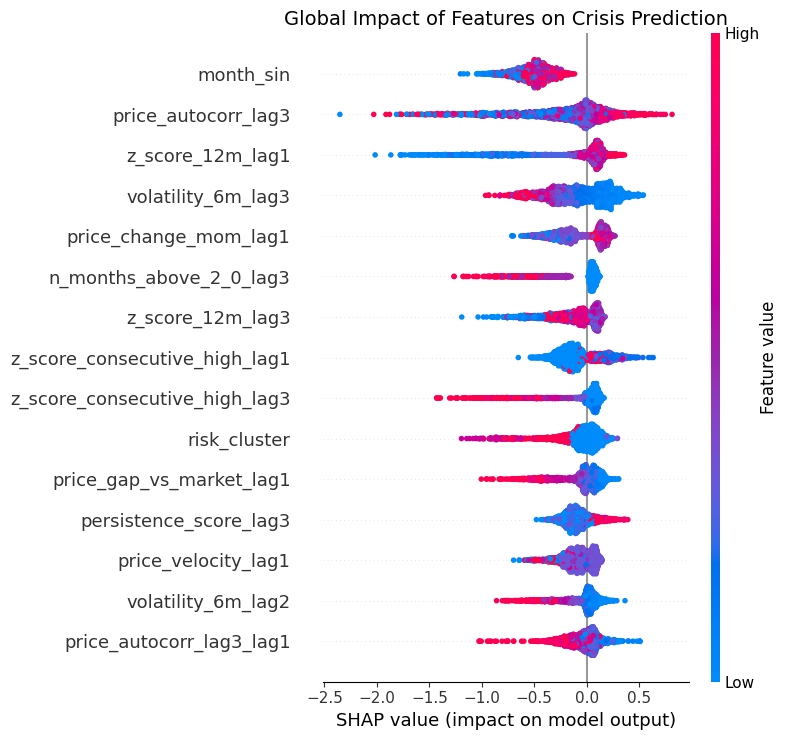

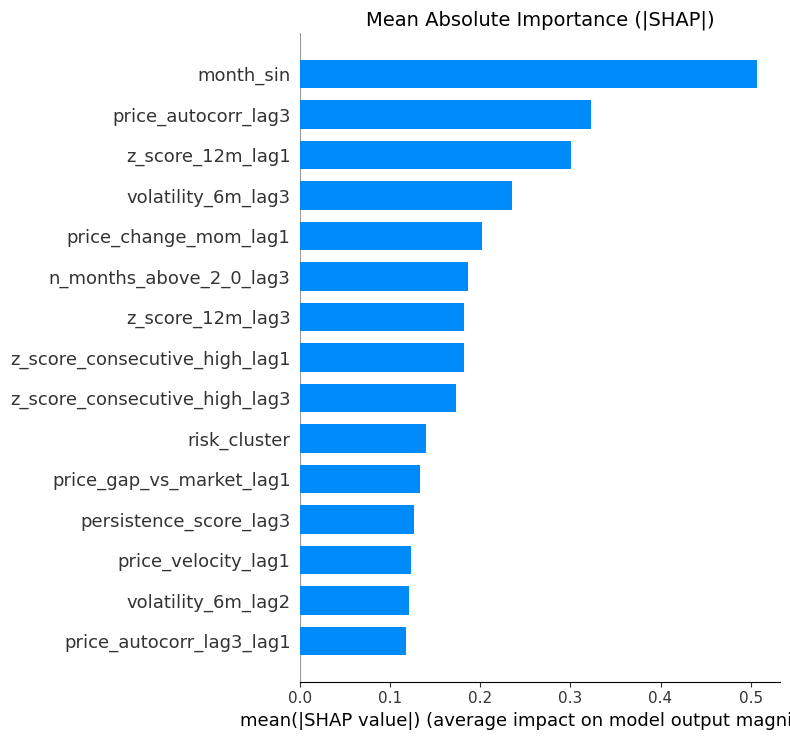


Zoom on non-linear effects (Top 4): ['month_sin', 'price_autocorr_lag3', 'z_score_12m_lag1', 'volatility_6m_lag3']


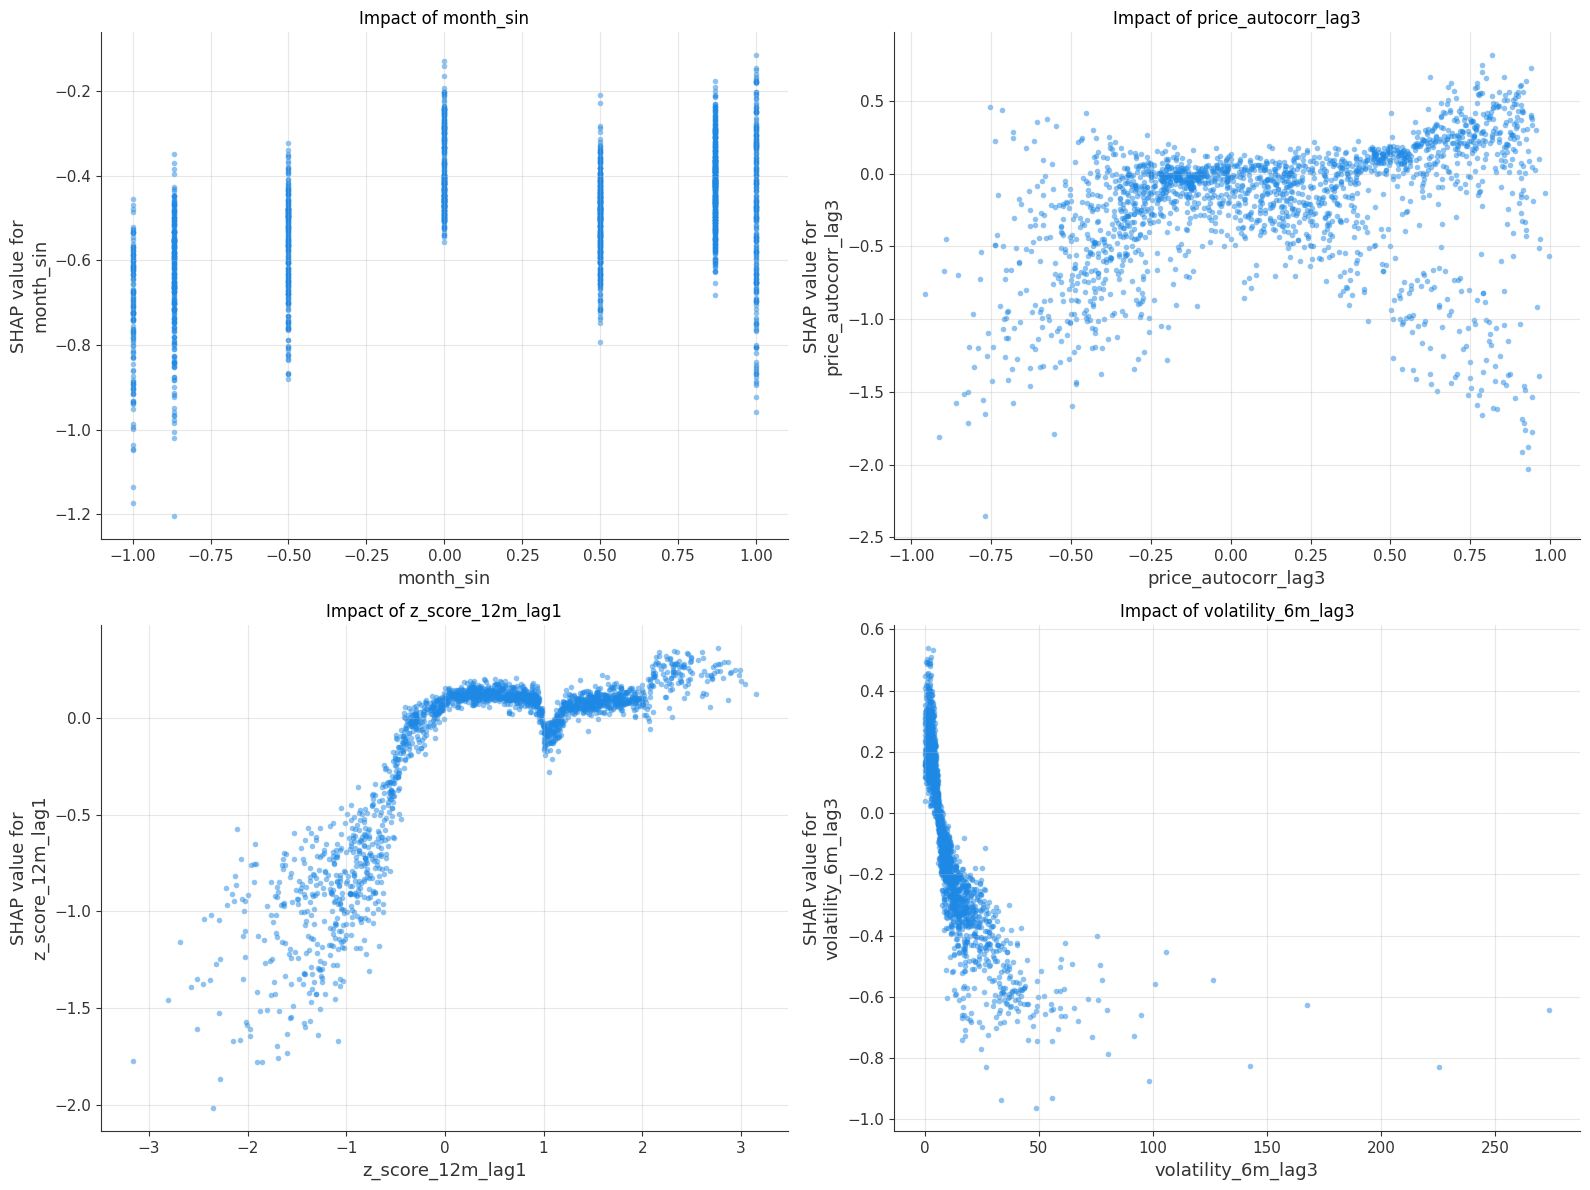


💡 INTERPRETATION:
1. Summary Plot: Look at the 'Red' tail. If it's to the right, high value = Risk.
2. Dependence Plot: Look for the threshold where the curve rises sharply (the 'Tipping Point').


In [11]:
print("="*80)
print("🔬 PART 6: INTERPRETABILITY ANALYSIS (SHAP VALUES)")
print("="*80)

# 1. ULTIMATE DATA CHECK
# ----------------------------------------------------------------
if 'model_final' not in globals() or 'scaler_final' not in globals():
    raise ValueError("❌ Model not found. Run the 'Step 1: The Bridge' block just above.")

if 'features_list' not in globals():
    if 'df_final' in globals():
        print("⚠️ 'features_list' missing, attempting reconstruction...")
        # Excluding non-feature columns
        exclude = ['adm0_name', 'mkt_name', 'cm_name', 'date', 'mp_year', 'mp_month',
                   'mp_price', 'Persistent_Shock', 'Choc_Persistant', 'Persistent_Shock_v2', 'Crisis_Alert',
                   'cur_name', 'um_name', 'pt_name', 'commodity_type']
        features_list = [c for c in df_final.columns if c not in exclude and df_final[c].dtype != 'object']
    else:
        raise ValueError("❌ 'features_list' and 'df_final' not found. Rerun Part 3.")

# 2. SAMPLE PREPARATION
# ----------------------------------------------------------------
# Recreating the exact list of features used by the model (Lag Only)
strict_features = [c for c in features_list if ('lag' in c) or (c in ['risk_cluster', 'month_sin', 'month_cos', 'stl_seasonal_component'])]

# Resume dataset
# Check for target column name
target_col = 'Persistent_Shock' if 'Persistent_Shock' in df_final.columns else 'Choc_Persistant'

df_shap = df_final.dropna(subset=strict_features + [target_col]).copy()
df_shap = df_shap.sort_values(['date', 'adm0_name', 'mkt_name', 'cm_name'])

# Take Test Set (most recent 20%)
split_idx = int(len(df_shap) * 0.80)
df_test_shap = df_shap.iloc[split_idx:].copy()

# Sampling (max 2000 points for speed)
if len(df_test_shap) > 2000:
    df_sample = df_test_shap.sample(2000, random_state=42)
else:
    df_sample = df_test_shap

print(f"Analysis on a sample of {len(df_sample)} observations (Test Set).")

# 3. SHAP CALCULATION
# ----------------------------------------------------------------
# Raw Data (for display)
X_raw = df_sample[strict_features]

# Scaled Data (for the model)
X_scaled = scaler_final.transform(X_raw.values)
X_scaled_df = pd.DataFrame(X_scaled, columns=strict_features)

print("Calculating SHAP values (patience, ~30 seconds)...")
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_scaled_df)
print("✅ Calculation complete.")

# 4. VISUALIZATIONS
# ----------------------------------------------------------------

# A. SUMMARY PLOT (Overview)
plt.figure(figsize=(10, 8))
plt.title("Global Impact of Features on Crisis Prediction", fontsize=14)
shap.summary_plot(shap_values, X_raw, show=False, max_display=15)
plt.tight_layout()
plt.show()

# B. FEATURE IMPORTANCE (Bars)
plt.figure(figsize=(8, 6))
plt.title("Mean Absolute Importance (|SHAP|)", fontsize=14)
shap.summary_plot(shap_values, X_scaled_df, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.show()

# C. DEPENDENCE PLOTS (Top 4 Features)
# Identifying the 4 most important ones
mean_shap = np.abs(shap_values).mean(axis=0)
top_indices = np.argsort(mean_shap)[::-1][:4]
top_features_names = [strict_features[i] for i in top_indices]

print(f"\nZoom on non-linear effects (Top 4): {top_features_names}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features_names):
    shap.dependence_plot(
        feat,
        shap_values,
        X_raw, # Passing raw values for X-axis (readable)
        ax=axes[i],
        show=False,
        interaction_index=None,
        alpha=0.5
    )
    axes[i].set_title(f"Impact of {feat}", fontsize=12)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
print("1. Summary Plot: Look at the 'Red' tail. If it's to the right, high value = Risk.")
print("2. Dependence Plot: Look for the threshold where the curve rises sharply (the 'Tipping Point').")

#QUANTILE REGRESSOR & ALERT LEVELS


🚀 STARTING SYSTEM V8 (FINAL: HYBRID & CALIBRATED INTELLIGENCE)
🤖 Generating predictions (Classification + Quantiles)...
   -> Training Quantile Regressors (q05, q50, q95)...
      - Quantile 05% | Best Iter: 198 | Pinball Loss: 0.0915
      - Quantile 50% | Best Iter: 199 | Pinball Loss: 0.3631
      - Quantile 95% | Best Iter: 198 | Pinball Loss: 0.0914
🔧 Calibration V8 (Relative + Absolute)...

🧠 Applying V8 Decision Logic...

📊 V8 Confusion Matrix (Final):


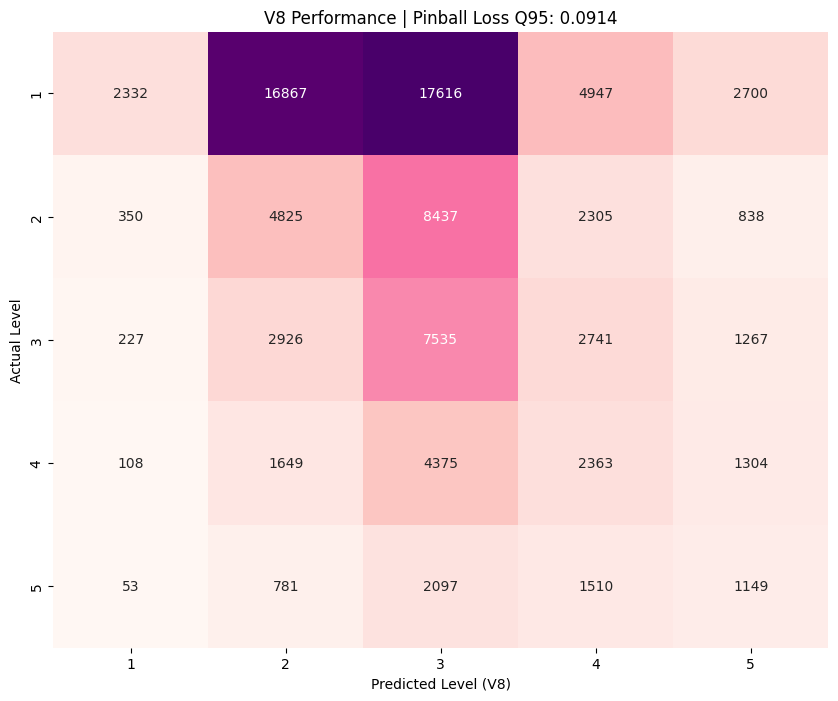

⚠️ Missed Famines (Lev 1-2): 834 / 5590 (14.9%)

--- 🏁 Quantile Loss Report (Pinball Loss) ---
Median (q50) : 0.3631 (Central Precision)
Extreme (q95): 0.0914 (Peak Detection Capacity)


In [12]:
# ============================================================================
# 1. METRIC: PINBALL LOSS (Quantile Loss)
# ============================================================================

def mean_pinball_loss(y_true, y_pred, alpha):
    """
    Calculates the mean Pinball Loss (or Quantile Loss).
    This is the standard metric for evaluating quantile regression quality.

    alpha : the target quantile (e.g., 0.95)
    """
    residual = y_true - y_pred
    return np.mean(np.maximum(alpha * residual, (alpha - 1) * residual))

# ============================================================================
# 2. XGBOOST QUANTILE TRAINING (With Loss Calculation)
# ============================================================================

def train_evaluate_quantiles_xgb(X_train, y_train, X_test, y_test):
    """
    Trains and evaluates XGBoost quantile regressors (q05, q50, q95).
    Returns models, predictions, and Pinball Loss scores.
    """
    quantiles = [0.05, 0.50, 0.95] # q05 (low), q50 (median), q95 (extreme)
    q_models = {}
    q_preds = {}
    q_losses = {} # Score storage

    print("   -> Training Quantile Regressors (q05, q50, q95)...")

    for q in quantiles:
        # XGBoost parameters for quantile regression
        q_params = {
            'objective': 'reg:quantileerror',
            'quantile_alpha': q,
            'eval_metric': 'rmse', # RMSE is often more stable for early stopping
            'n_estimators': 200,
            'learning_rate': 0.1,
            'max_depth': 5,
            'subsample': 0.7,
            'colsample_bytree': 0.7,
            'random_state': 42,
            'n_jobs': -1,
            'early_stopping_rounds': 20 # Stop if no improvement
        }

        model = xgb.XGBRegressor(**q_params)

        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)

        # Store Model
        q_models[f'q{int(q*100)}'] = model

        # Predict on Test
        pred = model.predict(X_test)
        q_preds[f'q{int(q*100)}'] = pred

        # --- CALCULATE PINBALL LOSS ---
        loss = mean_pinball_loss(y_test, pred, q)
        q_losses[f'q{int(q*100)}'] = loss

        # Logging
        best_iter = getattr(model, 'best_iteration', 'N/A')
        print(f"      - Quantile {q*100:02.0f}% | Best Iter: {str(best_iter):<3} | Pinball Loss: {loss:.4f}")

    return q_models, q_preds, q_losses

# ============================================================================
# 3. HYBRID SYSTEM V8 (FINAL: RELATIVE + ABSOLUTE)
# ============================================================================

def run_hybrid_system_v8_final(df, features_list, classifier_model, class_threshold):
    print("\n" + "="*80)
    print("🚀 STARTING SYSTEM V8 (FINAL: HYBRID & CALIBRATED INTELLIGENCE)")
    print("="*80)

    # --- A. DATA PREPARATION ---
    df_proc = df.copy().sort_values(['adm0_name', 'mkt_name', 'cm_name', 'date'])

    # Target Creation (Max Z-Score over the next 3 months)
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=3)
    df_proc['Target_Max_Z_3M'] = df_proc.groupby(['adm0_name', 'mkt_name', 'cm_name'])['z_score_12m'].transform(
        lambda x: x.shift(-1).rolling(window=indexer, min_periods=1).max()
    )

    # Cleaning and Features
    # Recreating the exact list of features used by the model (Lag Only)
    strict_features = [c for c in features_list if ('lag' in c) or (c in ['risk_cluster', 'month_sin', 'month_cos', 'stl_seasonal_component'])]

    # Check for target column name
    target_col = 'Persistent_Shock' if 'Persistent_Shock' in df.columns else 'Choc_Persistant'

    df_proc = df_proc.replace([np.inf, -np.inf], np.nan)
    df_clean = df_proc.dropna(subset=strict_features + [target_col, 'Target_Max_Z_3M']).copy()

    # Clipping (Outlier handling in inputs)
    for col in strict_features:
        if df_clean[col].dtype in [float, np.float32, np.float64]:
            lower = df_clean[col].quantile(0.001)
            upper = df_clean[col].quantile(0.999)
            df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    # Split Train/Test (Temporal)
    split_idx = int(len(df_clean) * 0.8)
    df_train = df_clean.iloc[:split_idx]
    df_test = df_clean.iloc[split_idx:].reset_index(drop=True)

    X_train = df_train[strict_features].values
    X_test = df_test[strict_features].values
    y_reg_train = df_train['Target_Max_Z_3M'].values
    y_reg_test = df_test['Target_Max_Z_3M'].values

    # Scaling
    scaler_hyb = StandardScaler()
    X_train_scaled = scaler_hyb.fit_transform(X_train)
    X_test_scaled = scaler_hyb.transform(X_test)

    # --- B. PREDICTIONS ---
    print("🤖 Generating predictions (Classification + Quantiles)...")

    # 1. Classification (Probability of crisis)
    probs = classifier_model.predict_proba(X_test_scaled)[:, 1]

    # 2. Quantile Regression (Potential severity)
    q_models, q_preds, q_losses = train_evaluate_quantiles_xgb(X_train_scaled, y_reg_train, X_test_scaled, y_reg_test)

    pred_q95_test = q_preds['q95'] # This is our "Worst Case" indicator

    # --- C. V8 CALIBRATION: DOUBLE SCALE ---
    print("🔧 Calibration V8 (Relative + Absolute)...")

    # Relative Scale (Model position relative to its training history)
    pred_q95_train = q_models['q95'].predict(X_train_scaled)
    ecdf_model = ECDF(pred_q95_train)
    pct_relatif = ecdf_model(pred_q95_test) * 100

    # Absolute Scale (Comparison with real historical severity)
    ecdf_real = ECDF(y_reg_train)
    pct_absolu = ecdf_real(pred_q95_test) * 100

    # --- D. DECISION LOGIC ---
    print("\n🧠 Applying V8 Decision Logic...")

    n = len(df_test)
    levels = np.zeros(n, dtype=int)
    reasons = np.full(n, "Normal", dtype=object)

    for i in range(n):
        p = probs[i]
        rel = pct_relatif[i]
        abs_val = pct_absolu[i]
        z_pred = pred_q95_test[i]

        # LEVEL 5: FAMINE (Circuit Breaker)
        if z_pred >= 3.0:
            levels[i] = 5; reasons[i] = f"FORCE MAJEURE (Z={z_pred:.1f})"
            continue

        # Strong Convergence
        if (p > class_threshold and abs_val >= 98) or (rel >= 99):
            levels[i] = 5; reasons[i] = "FAMINE (Convergence)"
            continue

        # LEVEL 4: EMERGENCY
        if rel >= 90 and abs_val >= 90:
            levels[i] = 4; reasons[i] = "EMERGENCY (Double High)"
        elif p > class_threshold and rel >= 80:
            levels[i] = 4; reasons[i] = "EMERGENCY (Proba + Severity)"

        # LEVEL 3: CRISIS
        elif (p > class_threshold) or (rel >= 80):
            levels[i] = 3; reasons[i] = "CRISIS"

        # LEVEL 2: WATCH
        elif (p > 0.15) or (rel >= 60):
            levels[i] = 2; reasons[i] = "Watch"

        # LEVEL 1
        else:
            levels[i] = 1; reasons[i] = "Normal"

    # --- E. RESULTS & EVALUATION ---
    df_res = df_test.copy()
    df_res['Probability'] = probs
    df_res['Severity_Q95'] = pred_q95_test
    df_res['Alert_Level_Final'] = levels
    df_res['Reason'] = reasons
    df_res['Actual_Max_Z'] = y_reg_test

    # Confusion Matrix
    print("\n📊 V8 Confusion Matrix (Final):")
    true_levels = np.ones(n, dtype=int)
    true_levels[y_reg_test >= 2.5] = 5
    true_levels[(y_reg_test >= 2.0) & (y_reg_test < 2.5)] = 4
    true_levels[(y_reg_test >= 1.5) & (y_reg_test < 2.0)] = 3
    true_levels[(y_reg_test >= 1.0) & (y_reg_test < 1.5)] = 2

    cm = confusion_matrix(true_levels, levels, labels=[1, 2, 3, 4, 5])

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", cbar=False,
                xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel("Predicted Level (V8)")
    plt.ylabel("Actual Level")
    plt.title(f"V8 Performance | Pinball Loss Q95: {q_losses['q95']:.4f}")
    plt.show()

    # Critical Safety Check
    critiques_rates = cm[4, 0] + cm[4, 1]
    total_famines = cm[4,:].sum()
    if total_famines > 0:
        print(f"⚠️ Missed Famines (Lev 1-2): {critiques_rates} / {total_famines} ({(critiques_rates/total_famines)*100:.1f}%)")
    else:
        print("No actual famine in the test set.")

    return df_res, q_models, scaler_hyb, ecdf_real, q_losses

# ============================================================================
# EXECUTION
# ============================================================================

if 'model_final' in globals() and 'df_final' in globals():
    thresh = opt_thresh if 'opt_thresh' in globals() else 0.5

    # Call the updated function
    alerts_v8, q_models, scaler, ecdf_real, pinball_losses = run_hybrid_system_v8_final(
        df_final, features_list, model_final, thresh
    )

    alerts_final = alerts_v8

    print("\n--- 🏁 Quantile Loss Report (Pinball Loss) ---")
    print(f"Median (q50) : {pinball_losses['q50']:.4f} (Central Precision)")
    print(f"Extreme (q95): {pinball_losses['q95']:.4f} (Peak Detection Capacity)")

#INTERRACTIVE DASHBOARD (STREAMLIT LINK)

In [13]:
print("💾 STEP 1: SAVING ARTIFACTS FOR DASHBOARD...")

# 1. Generate & Save SHAP Images
# ------------------------------------------------
print("   -> Generating SHAP images...")
try:
    if 'shap_values' in globals() and 'X_scaled_df' in globals():
        # Summary Plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_scaled_df, show=False, max_display=15)
        plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
        plt.close()

        # Dependence Plot (Top Feature)
        mean_shap = np.abs(shap_values).mean(axis=0)
        top_idx = np.argsort(mean_shap)[::-1][0]
        top_feat_name = X_scaled_df.columns[top_idx]

        plt.figure(figsize=(8, 6))
        shap.dependence_plot(top_feat_name, shap_values, X_scaled_df, show=False, interaction_index=None)
        plt.title(f"Dependence Plot: {top_feat_name}")
        plt.savefig('shap_dependence.png', bbox_inches='tight', dpi=150)
        plt.close()
        print(f"      - Saved dependence plot for: {top_feat_name}")
    else:
        print("⚠️ SHAP values not found in memory. Skipping images.")
except Exception as e:
    print(f"⚠️ Error saving SHAP images: {e}")

# 2. Save Data & Production Pack
# ------------------------------------------------
if 'alerts_final' in globals() and 'model_final' in globals():
    # A. Save the Dataframe
    alerts_final.to_pickle('df_dashboard.pkl')

    # B. Identify Top 4 Features for the Simulator
    importances = model_final.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_4_features = [features_list[indices[i]] for i in range(4)]

    # C. Create the Production Pack
    pack = {
        'model': model_final,
        'scaler': scaler_final,
        'features': features_list,
        'top_4_features': top_4_features, # Passed to the simulator
        'threshold': opt_thresh if 'opt_thresh' in globals() else 0.5,
        'ecdf': ecdf_real if 'ecdf_real' in globals() else None
    }

    with open('production_pack.pkl', 'wb') as f:
        pickle.dump(pack, f)

    print("✅ Success: 'df_dashboard.pkl' and 'production_pack.pkl' saved.")
else:
    print("❌ Error: 'alerts_final' or 'model_final' are missing. Please run the training pipeline first.")

💾 STEP 1: SAVING ARTIFACTS FOR DASHBOARD...
   -> Generating SHAP images...
      - Saved dependence plot for: month_sin
✅ Success: 'df_dashboard.pkl' and 'production_pack.pkl' saved.


<Figure size 800x600 with 0 Axes>

In [14]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.express as px
import plotly.graph_objects as go
import os

# --- PAGE CONFIGURATION ---
st.set_page_config(
    page_title="Global Food Watch | V8 AI System",
    page_icon="🌍",
    layout="wide",
    initial_sidebar_state="expanded"
)

# --- CUSTOM CSS ---
st.markdown("""
<style>
    .metric-card {
        background-color: #f8f9fa;
        border-radius: 10px;
        padding: 15px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.05);
    }
    .stTabs [data-baseweb="tab-list"] { gap: 8px; }
    h1, h2, h3 { color: #2c3e50; }

    /* Footer CSS */
    .footer {
        position: fixed;
        left: 0;
        bottom: 0;
        width: 100%;
        background-color: #f1f1f1;
        color: #555;
        text-align: center;
        padding: 10px;
        font-size: 14px;
        border-top: 1px solid #ddd;
        z-index: 100;
    }
    .content-footer {
        margin-top: 50px;
        padding-top: 20px;
        border-top: 1px solid #eee;
        text-align: center;
        color: #666;
        font-size: 14px;
    }
</style>
""", unsafe_allow_html=True)

# --- LOAD DATA ---
@st.cache_data
def load_assets():
    try:
        with open('df_dashboard.pkl', 'rb') as f:
            df = pickle.load(f)
        with open('production_pack.pkl', 'rb') as f:
            pack = pickle.load(f)
        return df, pack
    except Exception as e:
        return None, str(e)

df_alerts, pack = load_assets()

if df_alerts is None:
    st.error(f"❌ Critical Loading Error: {pack}")
    st.stop()

# Extract pack elements
model = pack['model']
scaler = pack['scaler']
features_list = pack['features']
top_4_feats = pack['top_4_features']
opt_threshold = pack['threshold']
ecdf = pack['ecdf']

# --- TRANSLATION MAPPING (French to English for Tab 1) ---
reason_mapping = {
    "Normal": "Normal",
    "Surveillance": "Watchlist",
    "CRISE": "Crisis",
    "URGENCE (Double Haut)": "Emergency (High Severity)",
    "URGENCE (Proba + Sévérité)": "Emergency (Prob + Sev)",
    "FAMINE (Convergence)": "Famine (Convergence)",
    "FORCE MAJEURE (Z-Pred > 3.0)": "Force Majeure (Z > 3.0)",
    "FORCE MAJEURE (Z-Pred=3.0)": "Force Majeure (Z > 3.0)"
}

# Apply mapping if column exists
if 'Reason' in df_alerts.columns:
    # We map only if the value exists in dictionary, else keep original
    df_alerts['Reason_EN'] = df_alerts['Reason'].map(lambda x: reason_mapping.get(str(x), str(x)))
else:
    df_alerts['Reason_EN'] = "N/A"

# --- SIDEBAR: FILTERS ---
st.sidebar.header("🔍 Filters")

# Country
countries = ['All'] + sorted(df_alerts['adm0_name'].unique().tolist())
sel_country = st.sidebar.selectbox("Country", countries)

# Market (Dynamic)
if sel_country != 'All':
    markets = ['All'] + sorted(df_alerts[df_alerts['adm0_name'] == sel_country]['mkt_name'].unique().tolist())
else:
    markets = ['All']
sel_market = st.sidebar.selectbox("Market", markets)

# Commodity
commodities = ['All'] + sorted(df_alerts['cm_name'].unique().tolist())
sel_commodity = st.sidebar.selectbox("Commodity", commodities)

# Alert Levels (DEFAULT: ALL 5 LEVELS)
sel_levels = st.sidebar.multiselect(
    "Alert Levels",
    [1, 2, 3, 4, 5],
    default=[1, 2, 3, 4, 5],
    format_func=lambda x: f"Level {x}"
)

# Date Range
min_date, max_date = df_alerts['date'].min(), df_alerts['date'].max()
sel_date = st.sidebar.slider("Period", min_date.date(), max_date.date(), (min_date.date(), max_date.date()))

# --- FILTERING LOGIC ---
df_filtered = df_alerts.copy()
if sel_country != 'All': df_filtered = df_filtered[df_filtered['adm0_name'] == sel_country]
if sel_market != 'All': df_filtered = df_filtered[df_filtered['mkt_name'] == sel_market]
if sel_commodity != 'All': df_filtered = df_filtered[df_filtered['cm_name'] == sel_commodity]

# Filter Levels & Date
df_filtered = df_filtered[df_filtered['Alert_Level_Final'].isin(sel_levels)]
df_filtered = df_filtered[(df_filtered['date'].dt.date >= sel_date[0]) & (df_filtered['date'].dt.date <= sel_date[1])]

# --- MAIN LAYOUT ---
st.title("🌍 Global Food Watch")
st.markdown("**Hybrid Early Warning System (XGBoost + Quantile Regression)**")

# KPIs
col1, col2, col3, col4 = st.columns(4)
with col1: st.metric("Observations (Filtered)", f"{len(df_filtered):,}")
with col2: st.metric("Critical Alerts (Lvl 4-5)", len(df_filtered[df_filtered['Alert_Level_Final'] >= 4]))
with col3: st.metric("Avg Severity (Percentile)", f"{df_filtered['Severity_Q95'].mean():.1f}%")
with col4: st.metric("Forecast Horizon", "3 Months")

# TABS
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "📊 Overview", "🗺️ Geography", "📈 Time Analysis", "🔬 Explainability", "🎮 Simulator V8"
])

# === TAB 1: OVERVIEW ===
with tab1:
    c1, c2 = st.columns([2, 1])
    with c1:
        st.subheader("Decision Matrix (Safety First)")
        # Scatter: Probability vs Severity
        # Downsample for speed if needed
        sample_df = df_filtered.sample(min(2000, len(df_filtered))) if len(df_filtered) > 0 else df_filtered

        fig = px.scatter(
            sample_df,
            x='Probability', y='Severity_Q95',
            color='Alert_Level_Final',
            color_continuous_scale='RdYlGn_r',
            hover_data=['adm0_name', 'mkt_name', 'cm_name', 'date'],
            height=450,
            title="Model Probability vs. Predicted Severity (Q95)"
        )
        # Threshold Lines
        fig.add_hline(y=3.0, line_dash="dash", line_color="red", annotation_text="Force Majeure (Z>3)")
        fig.add_vline(x=opt_threshold, line_dash="dot", line_color="blue", annotation_text=f"Opt. Threshold ({opt_threshold:.2f})")
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        st.subheader("Alert Distribution")
        counts = df_filtered['Alert_Level_Final'].value_counts().sort_index()
        colors = {1:'green', 2:'#ccff33', 3:'orange', 4:'red', 5:'darkred'}
        fig_pie = px.pie(values=counts.values, names=counts.index, color=counts.index, color_discrete_map=colors, hole=0.4)
        st.plotly_chart(fig_pie, use_container_width=True)

    st.subheader("🚨 Latest Critical Alerts")
    # Display dataframe with English Reasons
    display_cols = ['date', 'adm0_name', 'mkt_name', 'cm_name', 'Alert_Level_Final', 'Reason_EN', 'Severity_Q95']
    st.dataframe(
        df_filtered[df_filtered['Alert_Level_Final'] >= 4].sort_values('date', ascending=False).head(10)[display_cols],
        use_container_width=True
    )

# === TAB 2: GEOGRAPHY ===
with tab2:
    st.subheader("Risk Hotspots by Country")

    if len(df_filtered) > 0:
        # Aggregation
        country_stats = df_filtered.groupby('adm0_name').agg({
            'Alert_Level_Final': 'mean',
            'Severity_Q95': 'mean',
            'Probability': 'count' # Count
        }).rename(columns={'Probability': 'Alert_Count'}).reset_index().sort_values('Alert_Level_Final', ascending=False)

        col_g1, col_g2 = st.columns([2, 1])
        with col_g1:
            fig_bar = px.bar(
                country_stats.head(15),
                x='adm0_name', y='Alert_Level_Final',
                color='Severity_Q95', color_continuous_scale='Reds',
                title="Top 15 Countries by Average Risk Level",
                labels={'adm0_name': 'Country', 'Alert_Level_Final': 'Avg Alert Level'}
            )
            st.plotly_chart(fig_bar, use_container_width=True)

        with col_g2:
            st.dataframe(country_stats.style.background_gradient(cmap='Reds', subset=['Alert_Level_Final']), use_container_width=True, height=400)
    else:
        st.info("No data available for the current filters.")

# === TAB 3: TIME ANALYSIS ===
with tab3:
    st.header("📈 Temporal Risk Evolution")

    if len(df_filtered) > 0:
        # 1. Global Heatmap
        st.subheader("Global Risk Heatmap")
        df_heat = df_filtered.copy()
        df_heat['Month'] = df_heat['date'].dt.to_period('M').astype(str)

        # Pivot
        heatmap_data = df_heat.pivot_table(index='adm0_name', columns='Month', values='Alert_Level_Final', aggfunc='max').fillna(1)
        # Sort by risk
        risk_order = heatmap_data.mean(axis=1).sort_values(ascending=True).index
        heatmap_data = heatmap_data.reindex(risk_order)

        fig_heat = px.imshow(heatmap_data, aspect='auto', color_continuous_scale='RdYlGn_r', range_color=[1, 5], height=600)
        st.plotly_chart(fig_heat, use_container_width=True)

        st.markdown("---")

        # 2. Detailed Time Series (Requested Legend)
        st.subheader("Prediction vs. Reality Check")

        # Group by Date
        ts_data = df_filtered.groupby('date').agg({
            'Severity_Q95': 'mean',  # Average of the Predicted Max Risks
            'Actual_Max_Z': 'mean'   # Average of the Actual Max Z-Scores
        }).reset_index()

        fig_ts = go.Figure()

        # A. PREDICTION LINE
        fig_ts.add_trace(go.Scatter(
            x=ts_data['date'],
            y=ts_data['Severity_Q95'],
            mode='lines',
            name='Predicted Max Risk (Q95)',
            line=dict(color='red', width=2, dash='dash'),
            fill='tozeroy',
            fillcolor='rgba(255, 0, 0, 0.1)'
        ))

        # B. REALITY LINE
        fig_ts.add_trace(go.Scatter(
            x=ts_data['date'],
            y=ts_data['Actual_Max_Z'],
            mode='lines',
            name='Observed Severity (Average Real)',
            line=dict(color='black', width=3)
        ))

        fig_ts.update_layout(
            title="Validation: Model Predictions vs. Observed Reality (Average)",
            xaxis_title="Date",
            yaxis_title="Z-Score Severity",
            legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
            hovermode="x unified"
        )

        st.plotly_chart(fig_ts, use_container_width=True)
    else:
        st.info("No data available for the current filters.")

# === TAB 4: EXPLAINABILITY ===
with tab4:
    st.header("🔬 Why does the model predict a crisis?")
    c_sh1, c_sh2 = st.columns(2)

    with c_sh1:
        st.subheader("Global Feature Importance")
        if os.path.exists('shap_summary.png'):
            st.image('shap_summary.png', caption="Summary Plot: Which features drive risk up (red) or down (blue)?")
        else:
            st.warning("Summary plot image not found.")

    with c_sh2:
        st.subheader("Top Feature Interaction")
        if os.path.exists('shap_dependence.png'):
            st.image('shap_dependence.png', caption="Dependence Plot: Non-linear impact of the #1 feature.")
        else:
            st.warning("Dependence plot image not found.")

# === TAB 5: SIMULATOR ===
with tab5:
    st.header("🎮 V8 Crisis Simulator")
    st.markdown("Modify the **Top 4 Features** to see how the hybrid system reacts.")

    col_sim_in, col_sim_out = st.columns([1, 1])

    input_values = {}

    with col_sim_in:
        st.subheader("Scenario Parameters")

        # Dynamic Sliders for Top 4 Features
        for feat in top_4_feats:
            # We try to create intelligent ranges based on feature names
            clean_name = feat.replace('_lag1', '').replace('_', ' ').title()

            if 'z_score' in feat:
                val = st.slider(f"{clean_name} (Severity)", -2.0, 5.0, 1.5, 0.1)
            elif 'volatility' in feat:
                val = st.slider(f"{clean_name} (%)", 0.0, 100.0, 20.0, 1.0)
            elif 'price_change' in feat:
                val = st.slider(f"{clean_name} (%)", -20.0, 50.0, 5.0, 1.0)
            elif 'gap' in feat:
                val = st.slider(f"{clean_name} (%)", -50.0, 50.0, 10.0, 1.0)
            else:
                val = st.slider(f"{clean_name}", 0.0, 10.0, 0.0, 0.1)

            input_values[feat] = val

        btn_run = st.button("🚀 Run Simulation", type="primary")

    with col_sim_out:
        if btn_run:
            # 1. Construct Input Vector
            input_vec = np.zeros((1, len(features_list)))

            # Fill the known features
            for i, f_name in enumerate(features_list):
                if f_name in input_values:
                    input_vec[0, i] = input_values[f_name]
                if 'risk_cluster' in f_name:
                    input_vec[0, i] = 0

            # 2. Scale & Predict
            input_scaled = scaler.transform(input_vec)
            proba = model.predict_proba(input_scaled)[0, 1]

            # 3. Simulate Severity
            z_input = 0
            for k, v in input_values.items():
                if 'z_score' in k: z_input = v

            estimated_z_pred = z_input + (proba * 2.0)

            # 4. Calibration V8
            if ecdf:
                pct_absolu = ecdf(estimated_z_pred) * 100
            else:
                pct_absolu = 50

            # 5. Hybrid Logic V8
            level = 1
            reason = "Normal"

            if estimated_z_pred >= 3.0:
                level = 5; reason = "FORCE MAJEURE (Z > 3.0)"
            elif (proba > opt_threshold and pct_absolu >= 98):
                level = 5; reason = "FAMINE (Convergence)"
            elif (pct_absolu >= 90):
                level = 4; reason = "EMERGENCY (High Severity)"
            elif (proba > opt_threshold and pct_absolu >= 80):
                level = 4; reason = "EMERGENCY (Prob + Sev)"
            elif (proba > opt_threshold) or (pct_absolu >= 80):
                level = 3; reason = "CRISIS"
            elif (proba > 0.15) or (pct_absolu >= 60):
                level = 2; reason = "WATCHLIST"

            # 6. Display
            st.subheader("Simulation Results")
            c_res1, c_res2 = st.columns(2)
            c_res1.metric("Model Probability", f"{proba:.1%}")
            c_res2.metric("Est. Severity (Q95)", f"{estimated_z_pred:.2f} (Pct: {pct_absolu:.0f}%)")

            colors = {1:'green', 2:'#f1c40f', 3:'#e67e22', 4:'#e74c3c', 5:'#8b0000'}
            labels = {1:'NORMAL', 2:'WATCHLIST', 3:'CRISIS', 4:'EMERGENCY', 5:'FAMINE'}

            st.markdown(f"""
            <div style="background-color: {colors[level]}; color: white; padding: 25px; border-radius: 15px; text-align: center; margin-top: 20px;">
                <h1 style="color: white; margin:0;">LEVEL {level}</h1>
                <h2 style="color: white; margin:0;">{labels[level]}</h2>
                <hr style="border-color: rgba(255,255,255,0.3);">
                <p style="font-size: 18px;">Reason: {reason}</p>
            </div>
            """, unsafe_allow_html=True)

# --- FOOTER ---
st.markdown("""
<div class="content-footer">
    Global Food Watch App | Developer: <b>Romain Dulphy</b> | Contact: <b>Romain.dulphy@gmail.com</b>
</div>
""", unsafe_allow_html=True)
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ 'app.py' successfully created (English version with Footer).")

✅ 'app.py' successfully created (English version with Footer).


In [15]:
!pkill -9 streamlit
ngrok.kill()

# 2. Configure Ngrok
print("="*50)
print("🔑 NGROK CONFIGURATION")
print("="*50)

# We ask for the token immediately to avoid connection errors
# You can find it here: https://dashboard.ngrok.com/get-started/your-authtoken
auth_token = getpass.getpass("👉 Enter your ngrok Authtoken (starts with '2...'): ")

# We apply the token BEFORE attempting anything else
ngrok.set_auth_token(auth_token)

# 3. Start Streamlit in background (Force IPv4)
print("\n🚀 Starting Streamlit server...")
get_ipython().system_raw('nohup streamlit run app.py --server.port 8501 --server.address 127.0.0.1 > streamlit.log 2>&1 &')

# 4. Wait for initialization
print("⏳ Waiting 5 seconds for app to boot...")
time.sleep(5)

# 5. Check for errors
if os.path.exists("streamlit.log"):
    with open("streamlit.log", "r") as f:
        logs = f.read()
        # We check for fatal errors, but ignore common warnings
        if "Traceback" in logs and "Error" in logs:
            print("❌ STREAMLIT CRASHED! Logs:")
            print(logs)
        else:
            print("✅ Streamlit started successfully.")

# 6. Open Tunnel
try:
    # We specify the protocol explicitly
    public_url = ngrok.connect(8501, "http").public_url
    print(f"\n🎉 DASHBOARD ONLINE!")
    print(f"👉 Click here: {public_url}")
except Exception as e:
    print(f"❌ Ngrok Error: {e}")

🔑 NGROK CONFIGURATION
👉 Enter your ngrok Authtoken (starts with '2...'): ··········

🚀 Starting Streamlit server...
⏳ Waiting 5 seconds for app to boot...
✅ Streamlit started successfully.

🎉 DASHBOARD ONLINE!
👉 Click here: https://untoned-unsalved-dusty.ngrok-free.dev
